In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [87]:
df = pd.read_csv(r'fundo_amanha_dados_mock_2026.csv', sep=',', encoding='latin-1')


In [ ]:
display(df)

,corrida,qualidade,secao,sequencia,sequenciatotal,acoatual,al_min,c_min,c_max,n_min,s_min,corridasciclo,panela,vidapanela,temperaturaliquidus,temperaturaobjetivada,sugestaomodelolegado,temperaturasaidafp,tempociclo,temperaturamediareal
0,132228,F4A5E,300,5.0,8.0,V,0.01,0.35,0.37,0.01,0.045,6.0,7.0,32.0,1482.0,1532.0,1658.244263,1659.0,1593.0,1537.0
1,132227,F4A5E,300,4.0,8.0,V,0.01,0.35,0.37,0.01,0.045,5.0,2.0,16.0,1482.0,1532.0,1658.727173,1659.0,1364.0,1528.0
2,132226,F4A5E,300,3.0,8.0,V,0.01,0.35,0.37,0.01,0.045,4.0,4.0,50.0,1482.0,1532.0,1657.534302,1659.0,954.0,1533.0
3,132225,F4A5E,300,2.0,8.0,V,0.01,0.35,0.37,0.01,0.045,5.0,14.0,38.0,1482.0,1532.0,1649.176147,1652.0,1212.0,1546.0
4,132224,F4A5E,300,1.0,8.0,V,0.01,0.35,0.37,0.01,0.045,5.0,15.0,35.0,1482.0,1532.0,1661.008545,1664.0,1214.0,1534.0


In [89]:
df = df.drop_duplicates()
df = df.dropna()
df = df[df['temperaturamediareal'] >= 1000]
df = df[df['sugestaomodelolegado']>= -100]

In [90]:
# 1. Remover duplicatas primeiro (boa prática)
df = df.drop_duplicates()


# 2. Preencher os valores nulos ANTES de aplicar o filtro de limite (IQR)
# Assim não perdemos as linhas que poderiam ser salvas com a mediana
df['temperaturamediareal'] = df['temperaturamediareal'].fillna(df['temperaturamediareal'].median())
df['temperaturasaidafp'] = df['temperaturasaidafp'].fillna(df['temperaturasaidafp'].median())

# Verificando se os nulos foram tratados
print("Quantidade de valores nulos após tratamento inicial:")
print(df[['temperaturamediareal', 'temperaturasaidafp']].isnull().sum())

# 3. Função para remover outliers baseados no IQR
def filtrar_outliers_iqr(df, colunas):
    df_limpo = df.copy()
    for col in colunas:
        Q1 = df_limpo[col].quantile(0.25)
        Q3 = df_limpo[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inf = Q1 - 1.5 * IQR
        limite_sup = Q3 + 1.5 * IQR

        # Filtrando o dataframe
        df_limpo = df_limpo[(df_limpo[col] >= limite_inf) & (df_limpo[col] <= limite_sup)]
    return df_limpo

# 4. Aplicar o filtro nas colunas críticas (INCLUINDO a temperaturamediareal)
colunas_alvo = ['temperaturasaidafp', 'sugestaomodelolegado', 'temperaturamediareal']
df_filtered = filtrar_outliers_iqr(df, colunas_alvo)

print(f'\nTamanho original: {len(df)}')
print(f'Tamanho após remover outliers: {len(df_filtered)}')
print(f'Total de registros removidos (outliers): {len(df) - len(df_filtered)}')

# Atualizando o dataframe principal
df = df_filtered

Quantidade de valores nulos após tratamento inicial:
temperaturamediareal    0
temperaturasaidafp      0
dtype: int64

Tamanho original: 7087
Tamanho após remover outliers: 6634
Total de registros removidos (outliers): 453


In [91]:
# Início
display(df.head())
# Fim
display(df.tail())
print(df.info())

,corrida,qualidade,secao,sequencia,sequenciatotal,acoatual,al_min,c_min,c_max,n_min,s_min,corridasciclo,panela,vidapanela,temperaturaliquidus,temperaturaobjetivada,sugestaomodelolegado,temperaturasaidafp,tempociclo,temperaturamediareal
0,132228,F4A5E,300,5.0,8.0,V,0.01,0.35,0.37,0.01,0.045,6.0,7.0,32.0,1482.0,1532.0,1658.244263,1659.0,1593.0,1537.0
1,132227,F4A5E,300,4.0,8.0,V,0.01,0.35,0.37,0.01,0.045,5.0,2.0,16.0,1482.0,1532.0,1658.727173,1659.0,1364.0,1528.0
2,132226,F4A5E,300,3.0,8.0,V,0.01,0.35,0.37,0.01,0.045,4.0,4.0,50.0,1482.0,1532.0,1657.534302,1659.0,954.0,1533.0
3,132225,F4A5E,300,2.0,8.0,V,0.01,0.35,0.37,0.01,0.045,5.0,14.0,38.0,1482.0,1532.0,1649.176147,1652.0,1212.0,1546.0
4,132224,F4A5E,300,1.0,8.0,V,0.01,0.35,0.37,0.01,0.045,5.0,15.0,35.0,1482.0,1532.0,1661.008545,1664.0,1214.0,1534.0


,corrida,qualidade,secao,sequencia,sequenciatotal,acoatual,al_min,c_min,c_max,n_min,s_min,corridasciclo,panela,vidapanela,temperaturaliquidus,temperaturaobjetivada,sugestaomodelolegado,temperaturasaidafp,tempociclo,temperaturamediareal
7149,124600,FC47C,150,8.0,10.0,X,0.015,0.45,0.48,0.000,0.010,3.0,7.0,43.0,1482.0,1537.0,1641.839111,1643.0,589.0,1547.0
7150,122844,E1B6A,300,4.0,7.0,X,0.020,0.18,0.20,0.000,0.015,4.0,15.0,49.0,1501.0,1546.0,1656.897827,1647.0,921.0,1553.0
7151,122843,DCC51,300,3.0,7.0,V,0.010,0.29,0.32,0.012,0.030,6.0,1.0,53.0,1486.0,1536.0,1654.863770,1653.0,1771.0,1542.0
7152,122842,BCEE1,300,2.0,7.0,X,0.020,0.23,0.25,0.000,0.017,5.0,6.0,5.0,1497.0,1537.0,1652.258667,1649.0,1258.0,1542.0
7153,122837,9A58C,300,3.0,6.0,X,0.000,0.37,0.45,0.008,0.080,4.0,6.0,4.0,1480.0,1520.0,1625.990845,1630.0,992.0,1520.0


<class 'pandas.DataFrame'>
Index: 6634 entries, 0 to 7153
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   corrida                6634 non-null   int64  
 1   qualidade              6634 non-null   str    
 2   secao                  6634 non-null   int64  
 3   sequencia              6634 non-null   float64
 4   sequenciatotal         6634 non-null   float64
 5   acoatual               6634 non-null   str    
 6   al_min                 6634 non-null   float64
 7   c_min                  6634 non-null   float64
 8   c_max                  6634 non-null   float64
 9   n_min                  6634 non-null   float64
 10  s_min                  6634 non-null   float64
 11  corridasciclo          6634 non-null   float64
 12  panela                 6634 non-null   float64
 13  vidapanela             6634 non-null   float64
 14  temperaturaliquidus    6634 non-null   float64
 15  temperaturaobjetivad

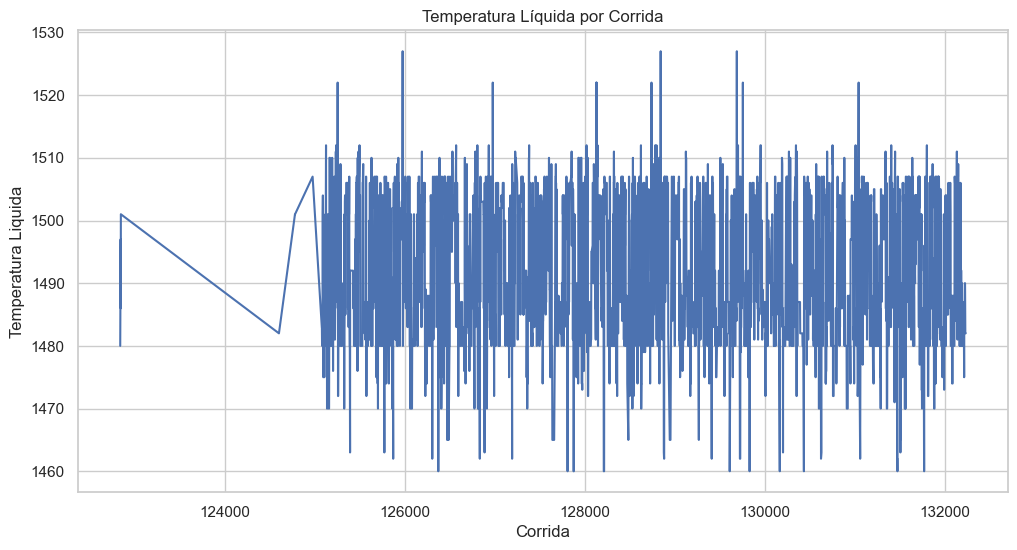

In [92]:
plt.figure(figsize=(12, 6))
plt.plot(df['corrida'], df['temperaturaliquidus'])
plt.xlabel('Corrida')
plt.ylabel('Temperatura Liquida')
plt.title('Temperatura Líquida por Corrida')
plt.grid(True)
plt.show()

In [93]:
# Calcular a matriz de correlação
correlation_matrix = df.corr(numeric_only=True)

# Exibir as primeiras linhas da matriz de correlação
display(correlation_matrix.head())

,corrida,secao,sequencia,sequenciatotal,al_min,c_min,c_max,n_min,s_min,corridasciclo,panela,vidapanela,temperaturaliquidus,temperaturaobjetivada,sugestaomodelolegado,temperaturasaidafp,tempociclo,temperaturamediareal
corrida,1.000000,0.256725,0.035832,0.060464,0.016388,0.004007,0.000060,0.008157,-0.043830,-0.029578,0.270187,-0.020969,0.004404,-0.035967,0.090963,0.115596,-0.042252,-0.075341
secao,0.256725,1.000000,-0.045130,-0.118903,-0.014366,-0.064670,-0.067558,-0.003474,-0.134908,-0.073556,0.079295,0.018196,0.088095,-0.129475,0.137774,0.149095,-0.085565,-0.069045
sequencia,0.035832,-0.045130,1.000000,0.402294,-0.000616,0.061783,0.059387,-0.064271,-0.022681,0.075681,0.019171,0.004691,-0.045553,0.004439,-0.292642,-0.238600,0.068796,0.021175
sequenciatotal,0.060464,-0.118903,0.402294,1.000000,-0.013283,0.164240,0.163343,-0.207731,-0.089528,0.059795,0.009966,0.003295,-0.146254,-0.015461,-0.130673,-0.158192,0.057864,-0.065893
al_min,0.016388,-0.014366,-0.000616,-0.013283,1.000000,-0.566178,-0.580064,0.143288,-0.403313,-0.030498,-0.015113,0.012516,0.675609,0.547156,0.419244,0.390315,-0.034499,0.494895


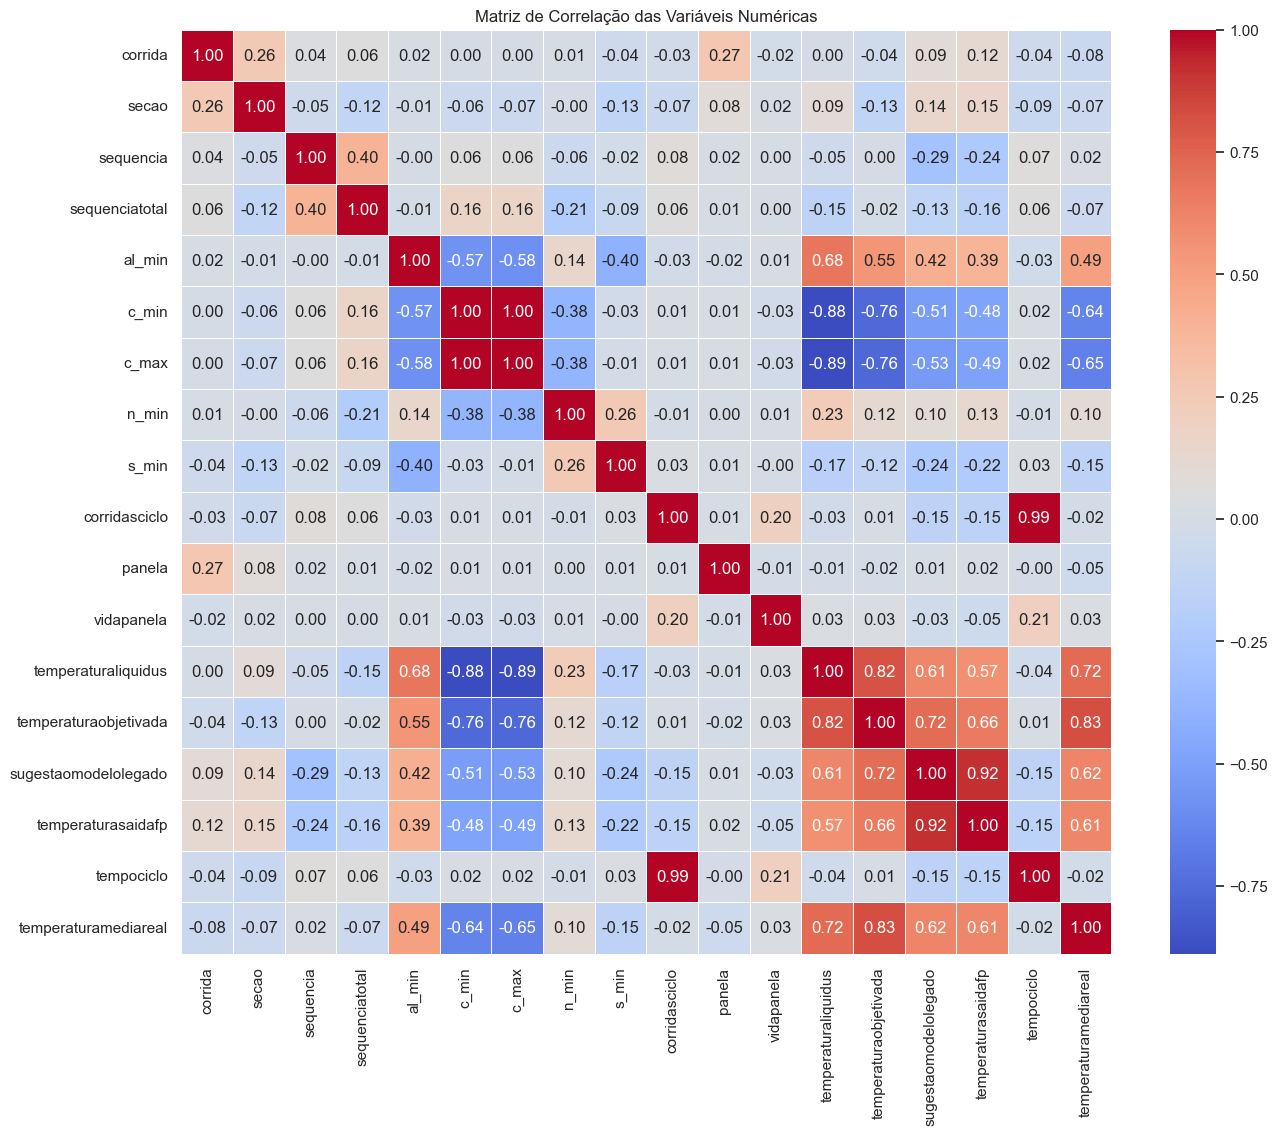

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

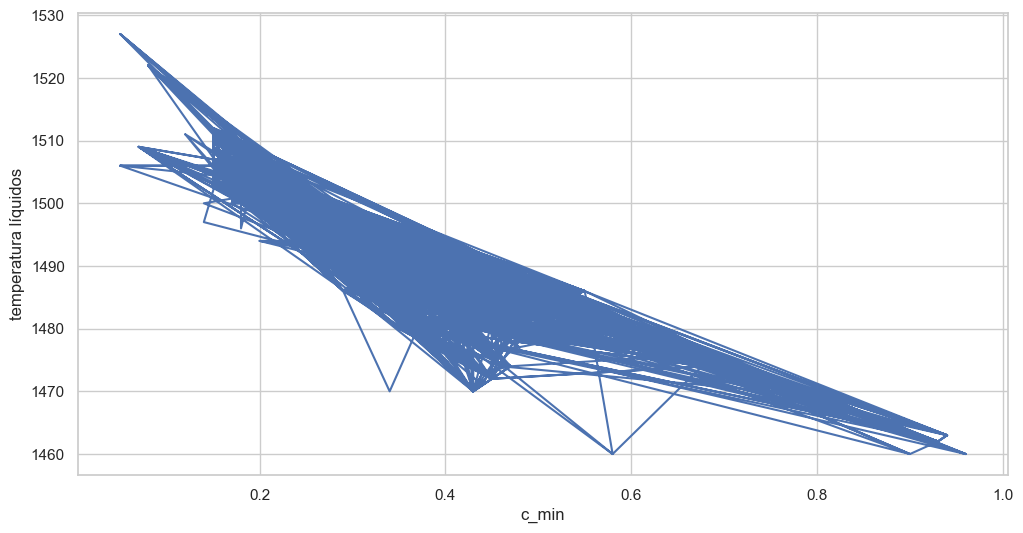

In [95]:
plt.figure(figsize=(12,6))
plt.plot(df['c_min'], df['temperaturaliquidus'])
plt.xlabel('c_min')
plt.ylabel('temperatura líquidos')
plt.grid(True)

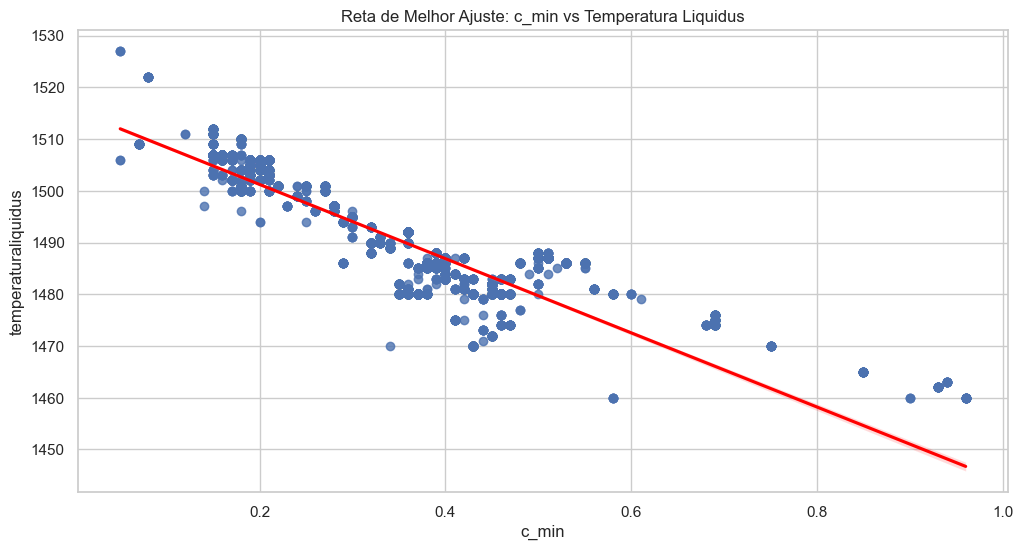

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
# O regplot desenha os pontos e a reta de regressão linear (fit)
sns.regplot(data=df, x='c_min', y='temperaturaliquidus', line_kws={'color': 'red'})

plt.title('Reta de Melhor Ajuste: c_min vs Temperatura Liquidus')
plt.grid(True)
plt.show()

In [97]:
print(correlation_matrix)

                        corrida     secao  sequencia  sequenciatotal  \
corrida                1.000000  0.256725   0.035832        0.060464   
secao                  0.256725  1.000000  -0.045130       -0.118903   
sequencia              0.035832 -0.045130   1.000000        0.402294   
sequenciatotal         0.060464 -0.118903   0.402294        1.000000   
al_min                 0.016388 -0.014366  -0.000616       -0.013283   
c_min                  0.004007 -0.064670   0.061783        0.164240   
c_max                  0.000060 -0.067558   0.059387        0.163343   
n_min                  0.008157 -0.003474  -0.064271       -0.207731   
s_min                 -0.043830 -0.134908  -0.022681       -0.089528   
corridasciclo         -0.029578 -0.073556   0.075681        0.059795   
panela                 0.270187  0.079295   0.019171        0.009966   
vidapanela            -0.020969  0.018196   0.004691        0.003295   
temperaturaliquidus    0.004404  0.088095  -0.045553       -0.14

In [98]:
lista = []

# Iterate over all possible pairs of columns
for col1 in correlation_matrix.columns:
    for col2 in correlation_matrix.columns:
        # Exclude self-correlation (correlation of a column with itself is always 1)
        if col1 != col2:
            correlation_value = correlation_matrix.loc[col1, col2]
            # Check if the correlation is strongly positive (between 0.5 and 0.999)
            # or strongly negative (between -1 and -0.5)
            if (0.5 < correlation_value < 0.999) or (-1 < correlation_value < -0.5):
                lista.append((col1, col2, correlation_value))

# You can now print or display the 'lista' to see the results
print("Strong Correlations found:")
for item in lista:
    print(f"Variable 1: {item[0]}, Variable 2: {item[1]}, Correlation: {item[2]:.4f}")

Strong Correlations found:
Variable 1: al_min, Variable 2: c_min, Correlation: -0.5662
Variable 1: al_min, Variable 2: c_max, Correlation: -0.5801
Variable 1: al_min, Variable 2: temperaturaliquidus, Correlation: 0.6756
Variable 1: al_min, Variable 2: temperaturaobjetivada, Correlation: 0.5472
Variable 1: c_min, Variable 2: al_min, Correlation: -0.5662
Variable 1: c_min, Variable 2: c_max, Correlation: 0.9958
Variable 1: c_min, Variable 2: temperaturaliquidus, Correlation: -0.8820
Variable 1: c_min, Variable 2: temperaturaobjetivada, Correlation: -0.7566
Variable 1: c_min, Variable 2: sugestaomodelolegado, Correlation: -0.5132
Variable 1: c_min, Variable 2: temperaturamediareal, Correlation: -0.6444
Variable 1: c_max, Variable 2: al_min, Correlation: -0.5801
Variable 1: c_max, Variable 2: c_min, Correlation: 0.9958
Variable 1: c_max, Variable 2: temperaturaliquidus, Correlation: -0.8878
Variable 1: c_max, Variable 2: temperaturaobjetivada, Correlation: -0.7641
Variable 1: c_max, Variab

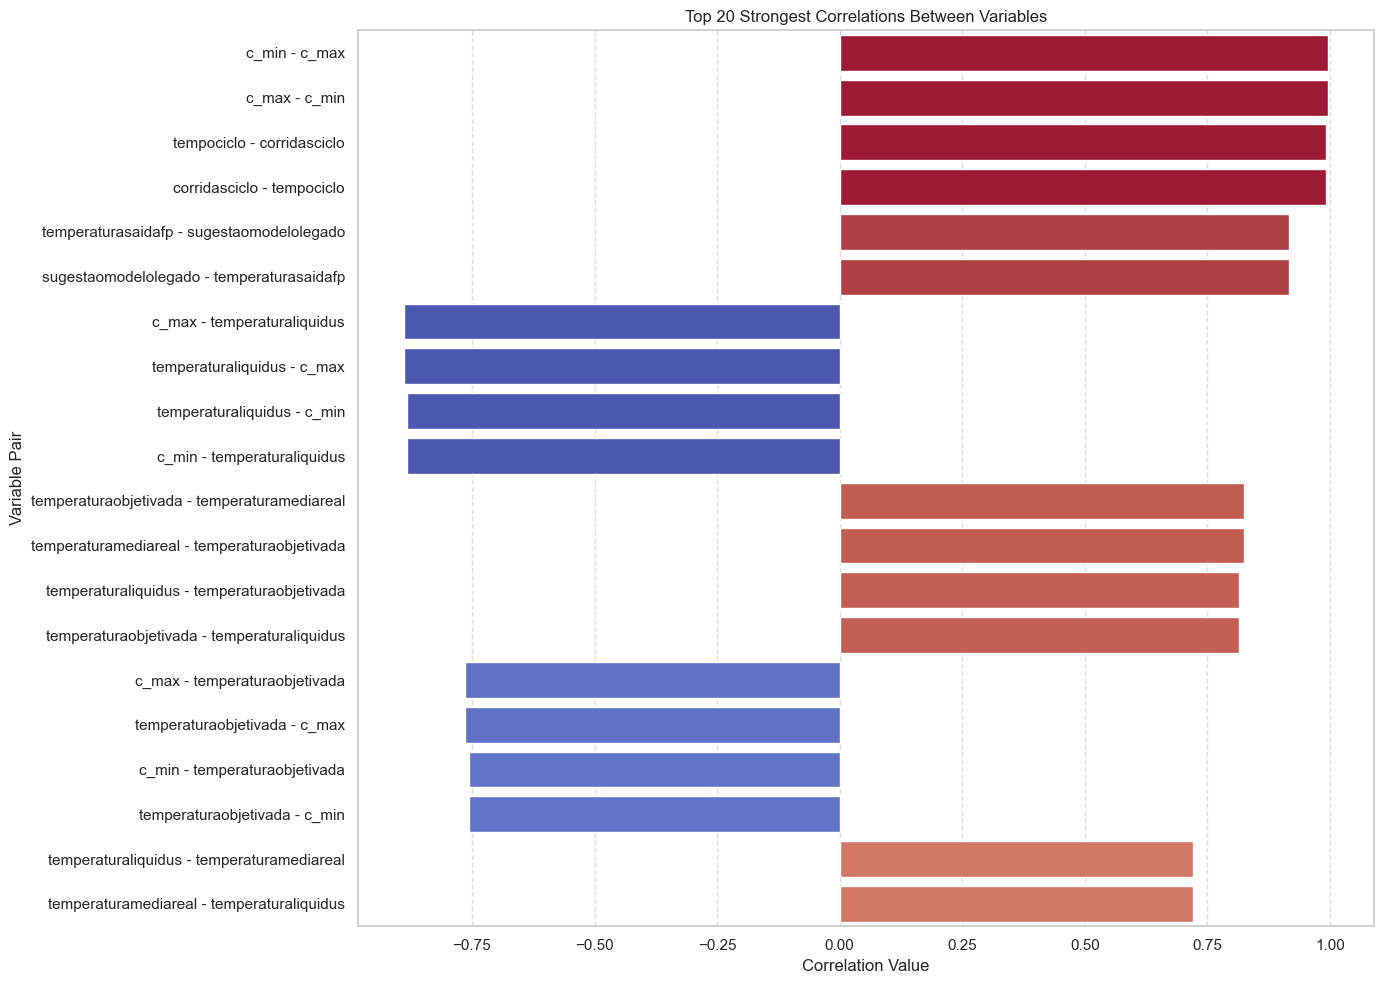

In [99]:
correlation_df = pd.DataFrame(lista, columns=['Variable 1', 'Variable 2', 'Correlation'])

# Sort by absolute correlation value to highlight the strongest ones
correlation_df['Abs_Correlation'] = correlation_df['Correlation'].abs()
correlation_df = correlation_df.sort_values(by='Abs_Correlation', ascending=False)

# Select only the top 20 strongest correlations for better readability
top_correlations = correlation_df.head(20)

plt.figure(figsize=(14, 10)) # Increased figure height for more labels
sns.barplot(x='Correlation', y=top_correlations['Variable 1'] + ' - ' + top_correlations['Variable 2'],
            data=top_correlations, palette='coolwarm', hue='Correlation', legend=False)
plt.title('Top 20 Strongest Correlations Between Variables')
plt.xlabel('Correlation Value')
plt.ylabel('Variable Pair')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

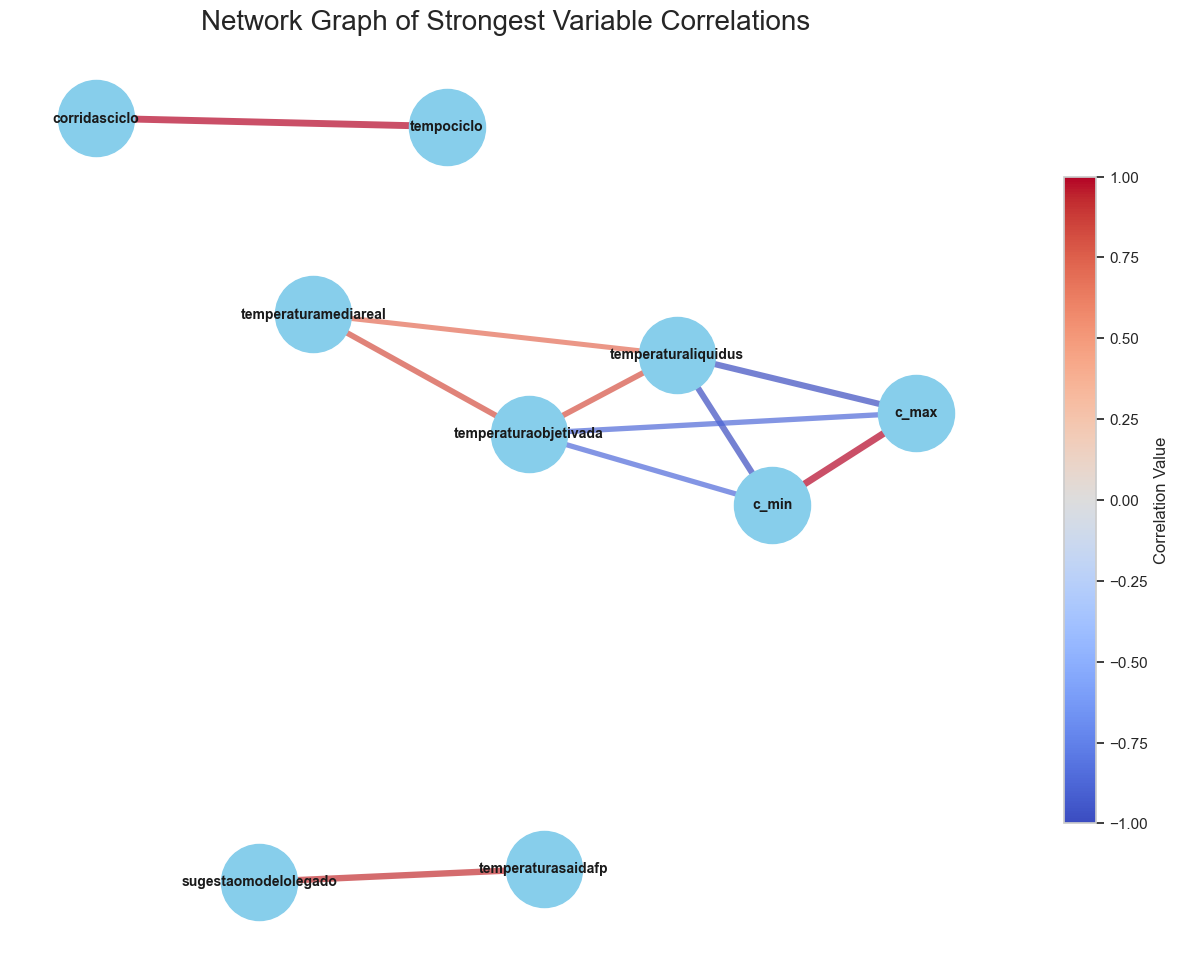

In [100]:
import networkx as nx
import matplotlib.pyplot as plt

# Ensure top_correlations is defined
# Sort by absolute correlation value to highlight the strongest ones
correlation_df['Abs_Correlation'] = correlation_df['Correlation'].abs()
correlation_df = correlation_df.sort_values(by='Abs_Correlation', ascending=False)
top_correlations = correlation_df.head(20)

# Create an empty graph
G = nx.Graph()

# Add nodes for all unique variables involved in the top correlations
all_variables = pd.concat([top_correlations['Variable 1'], top_correlations['Variable 2']]).unique()
G.add_nodes_from(all_variables)

# Add edges with correlation as a weight attribute
for index, row in top_correlations.iterrows():
    var1 = row['Variable 1']
    var2 = row['Variable 2']
    correlation = row['Correlation']
    abs_correlation = row['Abs_Correlation']
    G.add_edge(var1, var2, weight=abs_correlation, correlation_value=correlation)

# Define node positions using a spring layout
pos = nx.spring_layout(G, k=0.8, iterations=50) # k regulates the distance between nodes

plt.figure(figsize=(16, 12))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=3000)

# Draw edges
# Get edge weights and colors based on correlation strength and sign
edges = G.edges(data=True)
colors = [edge[2]['correlation_value'] for edge in edges]
widths = [edge[2]['weight'] * 5 for edge in edges] # Scale width by correlation strength

nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=colors, width=widths,
                       edge_cmap=plt.cm.coolwarm, alpha=0.7)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Add a color bar for correlation values
sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm)
sm.set_array([-1, 1]) # Range of correlations
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', pad=0.05, shrink=0.7)
cbar.set_label('Correlation Value')

plt.title('Network Graph of Strongest Variable Correlations', size=20)
plt.axis('off') # Hide the axis
plt.show()

### Gráfico de Quadrantes para Correlações Fortes

Este gráfico de quadrantes visualiza as correlações mais fortes identificadas. Cada ponto representa um par de variáveis com alta correlação (positiva ou negativa). A cor do ponto indica se a correlação é positiva ou negativa, facilitando a identificação rápida dos tipos de relacionamentos entre as variáveis. O eixo X mostra o valor da correlação e o eixo Y lista os pares de variáveis envolvidas.

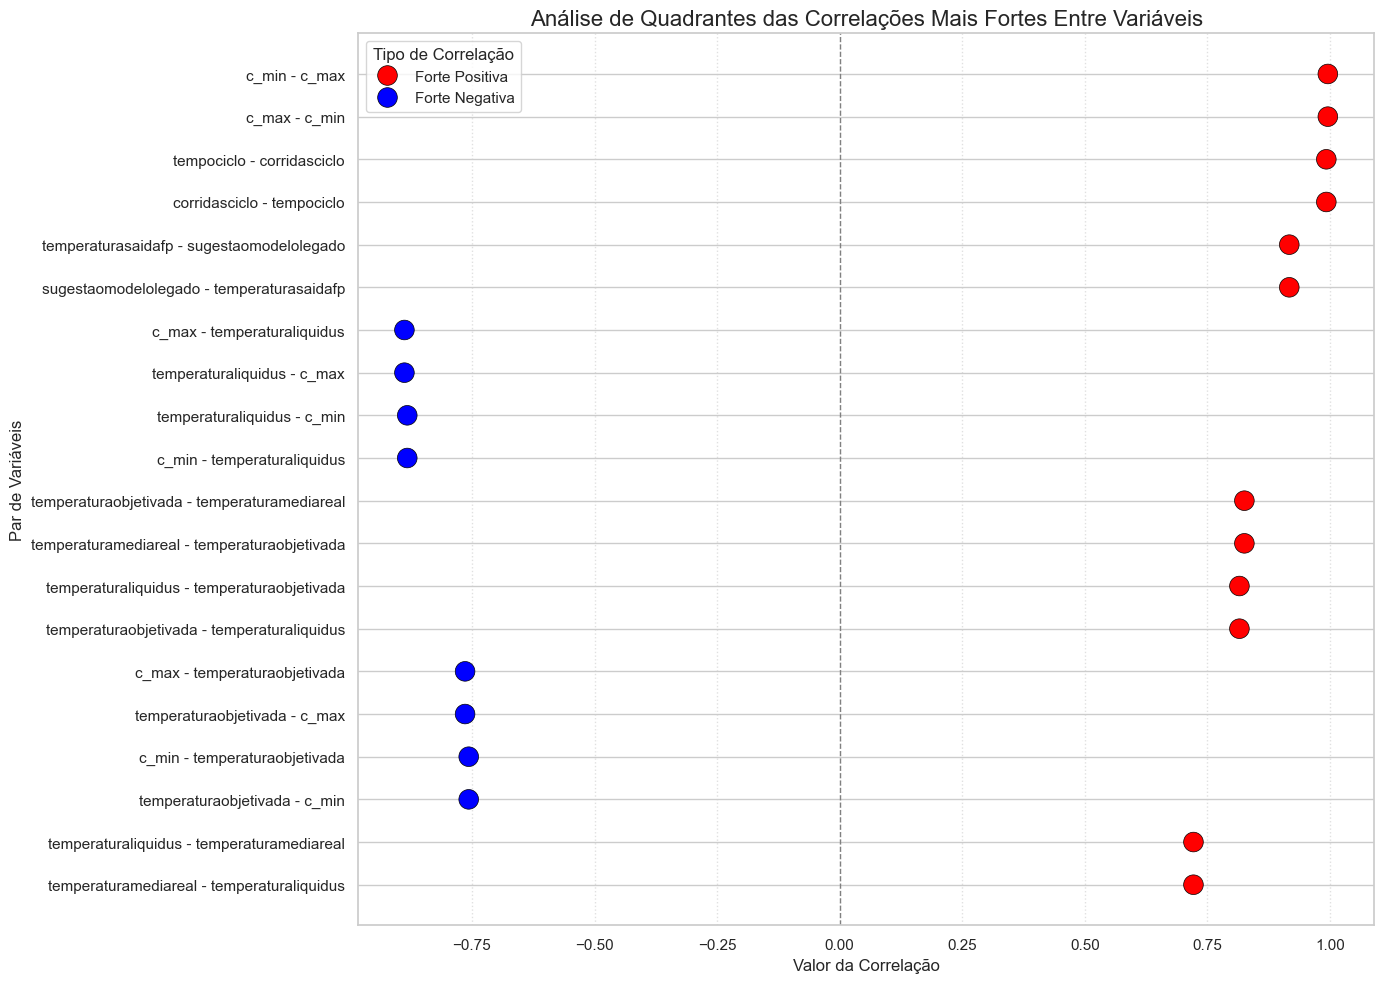

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

# Certificar que top_correlations está disponível e categorizado
# top_correlations já foi filtrado para correlações fortes (absolutas > 0.5)

top_correlations_plot = top_correlations.copy()
top_correlations_plot['Tipo de Correlação'] = top_correlations_plot['Correlation'].apply(lambda x: 'Forte Positiva' if x > 0 else 'Forte Negativa')

plt.figure(figsize=(14, 10))

# Criar o scatter plot
sns.scatterplot(
    x='Correlation',
    y=top_correlations_plot['Variable 1'] + ' - ' + top_correlations_plot['Variable 2'],
    hue='Tipo de Correlação',
    palette={'Forte Positiva': 'red', 'Forte Negativa': 'blue'},
    s=200, # tamanho dos pontos
    data=top_correlations_plot,
    edgecolor='black',
    linewidth=0.5
)

plt.axvline(x=0, color='gray', linestyle='--', linewidth=1) # Linha vertical em 0 correlação

plt.title('Análise de Quadrantes das Correlações Mais Fortes Entre Variáveis', size=16)
plt.xlabel('Valor da Correlação', size=12)
plt.ylabel('Par de Variáveis', size=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.legend(title='Tipo de Correlação')
plt.tight_layout()
plt.show()

Gerando 10 gráficos de dispersão com linha de ajuste...


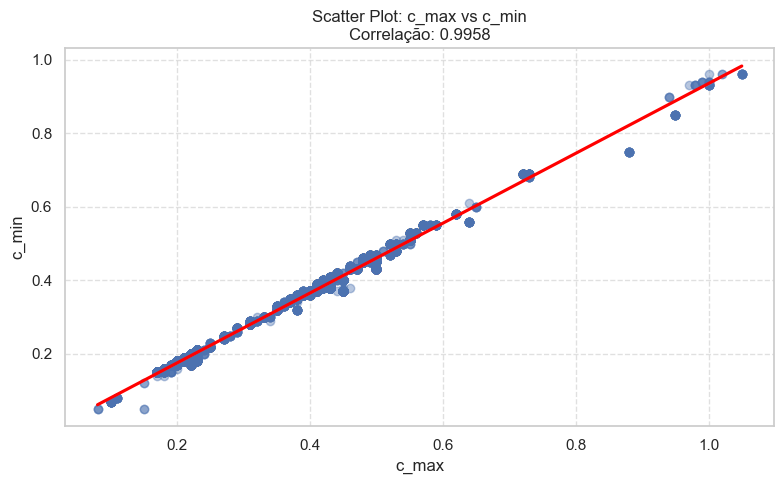

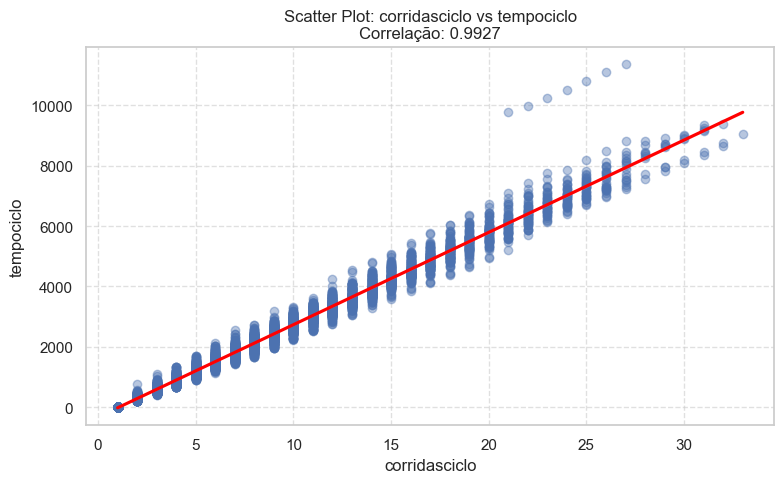

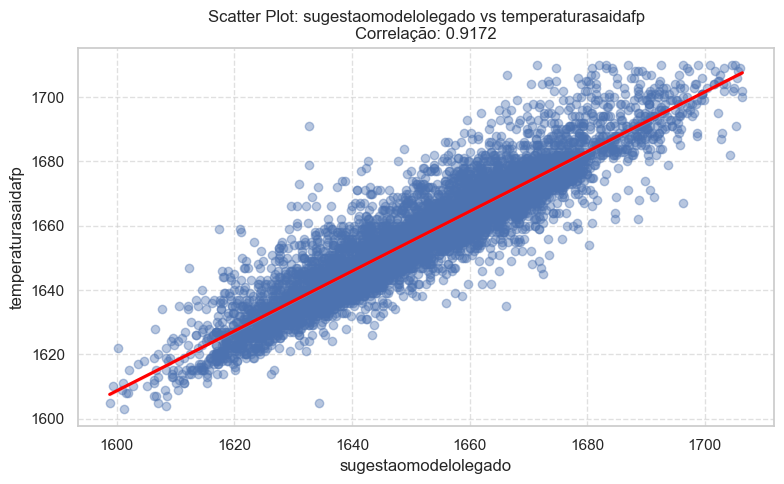

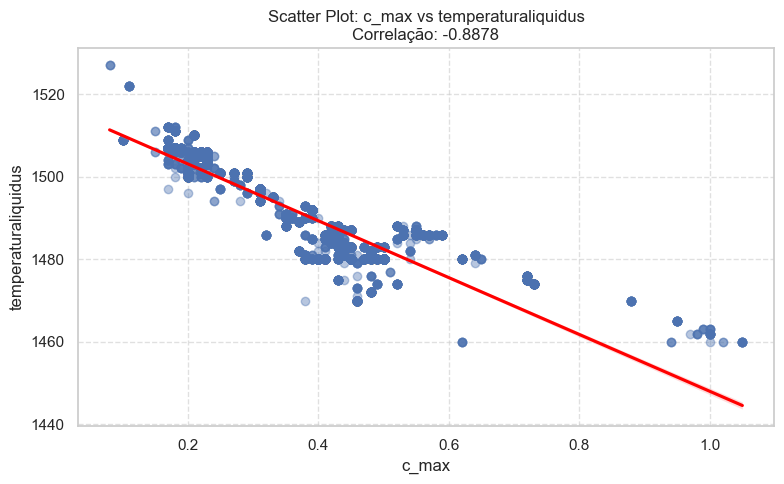

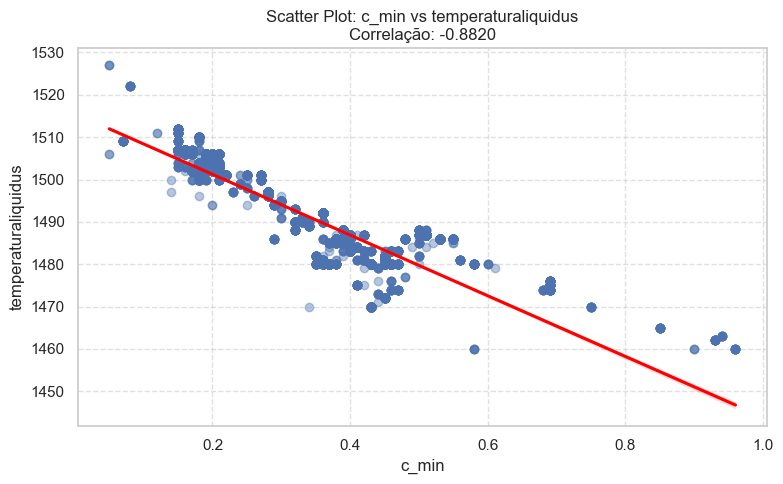

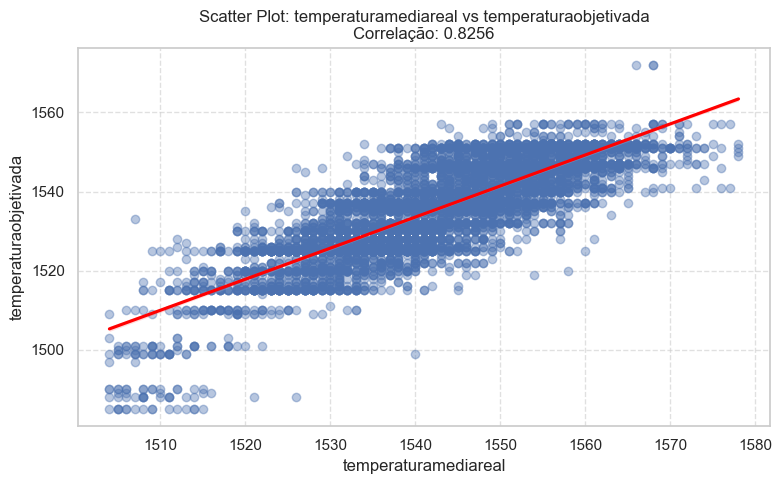

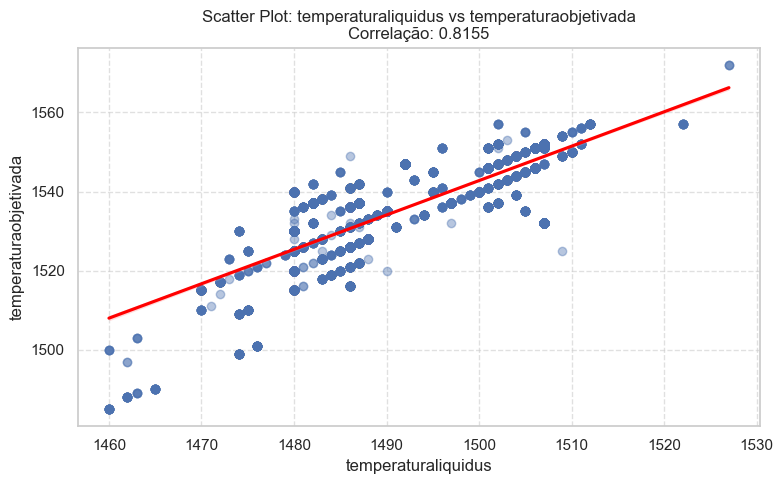

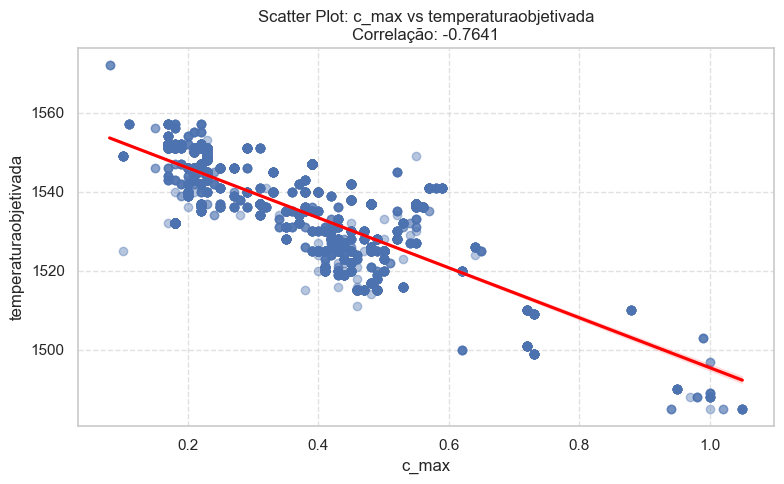

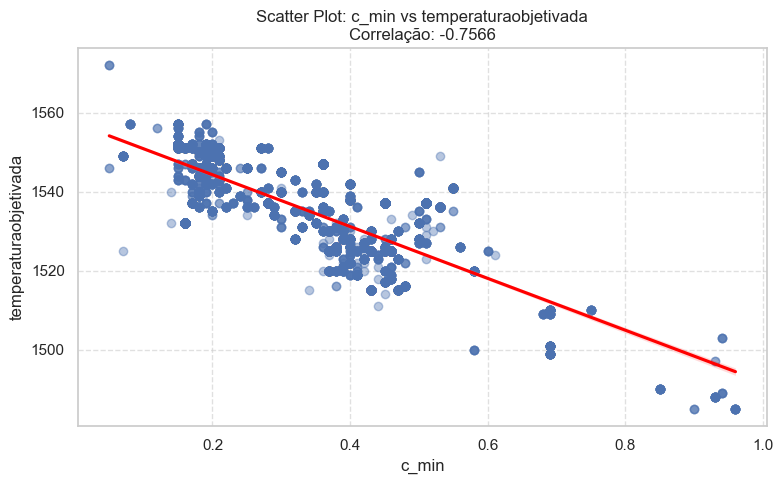

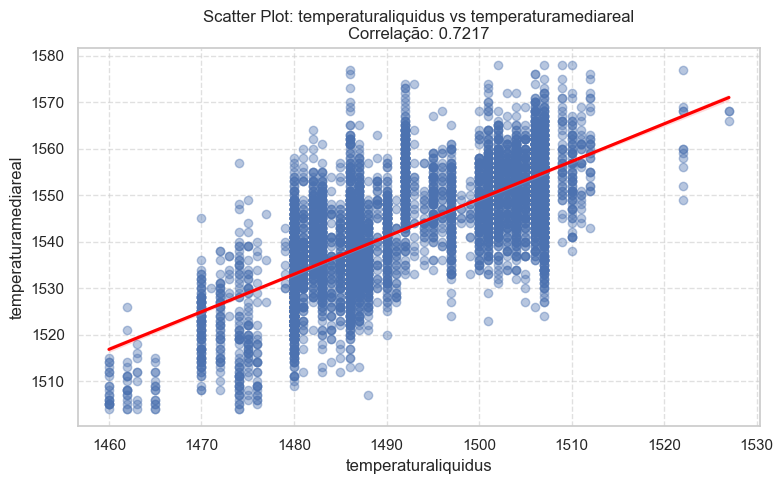

Finalizado.


In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Garantir que df e correlation_matrix existam
if 'df' not in locals():
    df = pd.read_csv('fundo_amanha_dados_mock_2026.csv', sep=',', encoding='latin-1')

correlation_matrix = df.corr(numeric_only=True)

lista = []
# Identificar correlações fortes (|r| > 0.5)
for col1 in correlation_matrix.columns:
    for col2 in correlation_matrix.columns:
        if col1 < col2:
            correlation_value = correlation_matrix.loc[col1, col2]
            if (0.5 < correlation_value < 0.999) or (-1 < correlation_value < -0.5):
                lista.append((col1, col2, correlation_value))

correlation_df = pd.DataFrame(lista, columns=['Variable 1', 'Variable 2', 'Correlation'])
correlation_df['Abs_Correlation'] = correlation_df['Correlation'].abs()
correlation_df = correlation_df.sort_values(by='Abs_Correlation', ascending=False)

# Gerar os top 10 gráficos
top_correlations = correlation_df.head(10)

print(f"Gerando {len(top_correlations)} gráficos de dispersão com linha de ajuste...")

for index, row in top_correlations.iterrows():
    var1 = row['Variable 1']
    var2 = row['Variable 2']
    correlation = row['Correlation']

    plt.figure(figsize=(8, 5))
    sns.regplot(data=df, x=var1, y=var2, line_kws={'color': 'red'}, scatter_kws={'alpha': 0.4})

    plt.title(f'Scatter Plot: {var1} vs {var2}\nCorrelação: {correlation:.4f}')
    plt.xlabel(var1)
    plt.ylabel(var2)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

print("Finalizado.")

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo visual
sns.set_theme(style="whitegrid")

# Carregar os dados do arquivo
df = pd.read_csv('fundo_amanha_dados_mock_2026.csv')

# 1. Calcular o erro do modelo legado
# Erro = Temperatura Real - Temperatura Objetivada
df['erro_legado'] = df['temperaturamediareal'] - df['temperaturaobjetivada']

# 2. Critério de acerto: erro entre -10°C e +20°C
df['acerto_legado'] = (df['erro_legado'] >= -10) & (df['erro_legado'] <= 20)

# Taxa de acerto geral
taxa = df['acerto_legado'].mean() * 100
print(f'Taxa de acerto do modelo legado: {taxa:.1f}%')

# Estatísticas descritivas do erro
print("\nEstatísticas do erro:")
print(df['erro_legado'].describe().round(2).to_string())

# 3. Distribuição do erro (Plotagem)
sns.histplot(df['erro_legado'], kde=True, bins=40, color='steelblue')
plt.axvline(0, color='green', linestyle='--', label='Erro zero (perfeito)')
plt.axvline(-10, color='red', linestyle=':', label='Limite inferior (-10°C)')
plt.axvline(20, color='orange', linestyle=':', label='Limite superior (+20°C)')

# Preenchimento visual da região considerada "Zona de acerto"
y_bounds = plt.gca().get_ylim()
plt.fill_betweenx([0, y_bounds[1] if y_bounds[1] else 1], -10, 20, alpha=0.1, color='green', label='Zona de acerto')

plt.title(f'Distribuição do Erro — Modelo Legado (acerto: {taxa:.1f}%)')
plt.xlabel('Erro (°C): Temp. Real − Temp. Objetivada')
plt.ylabel('Contagem')
plt.legend()
plt.tight_layout()
plt.savefig('erro_legado.png', dpi=150)
plt.close()

# 4. Taxa de acerto por qualidade de aço
acerto_por_qualidade = df.groupby('qualidade')['acerto_legado'].agg(['mean','count'])
acerto_por_qualidade['mean'] = (acerto_por_qualidade['mean'] * 100).round(1)
print("\nTaxa de acerto por qualidade:")
print(acerto_por_qualidade.sort_values('mean').to_string())

# 5. Avaliação de comportamento do operador vs modelo legado
df['diferenca_operador_legado'] = df['temperaturasaidafp'] - df['sugestaomodelolegado']
print(f'\nDesvio médio operador vs legado: {df["diferenca_operador_legado"].mean():.2f}°C')
print(f'Desvio mediano operador vs legado: {df["diferenca_operador_legado"].median():.2f}°C')

Taxa de acerto do modelo legado: 95.3%

Estatísticas do erro:
count    7094.00
mean        6.67
std        18.93
min     -1460.00
25%         2.00
50%         7.00
75%        12.00
max        41.00

Taxa de acerto por qualidade:
            mean  count
qualidade              
4700C       50.0      2
E1FC0       50.0      2
3CF26       60.0     20
6CBE8       62.5      8
5E13D       64.6     48
509A2       66.7      3
8ECC3       66.7      3
7C2F1       66.7      3
EDD03       71.4      7
EB041       71.4     14
8D915       75.0      8
D6B63       75.0      4
66364       75.0      4
A282D       75.0      4
15370       75.0     12
16DAA       75.0      8
FB6D2       75.0      4
F32D6       75.0      4
CE16F       80.0     10
603D2       80.0     10
51C01       81.8     11
FC570       83.3      6
E198F       83.3     24
000DC       83.3     12
80160       86.2    123
F9D23       87.5      8
B0EC5       88.2     17
DDC4A       88.2     17
27480       88.6     35
4E04A       88.9     27
0BF

Taxa de acerto do modelo legado: 95.3%


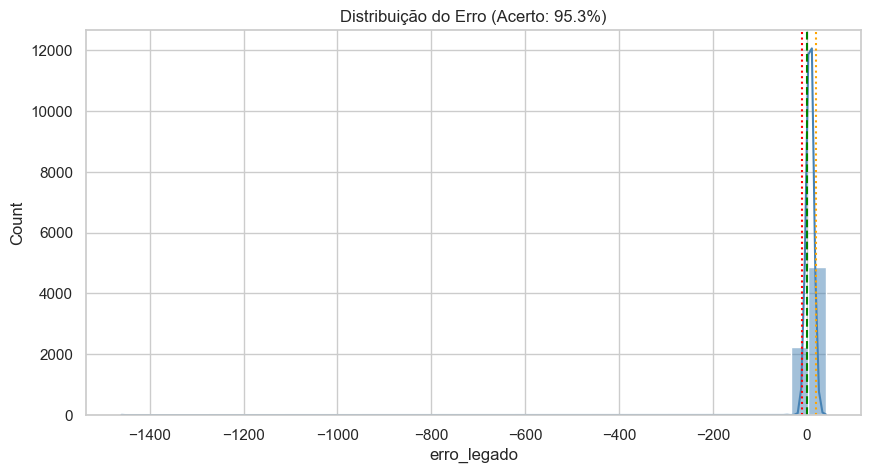

C:\Users\Usuário\AppData\Local\Temp\ipykernel_6016\3040286960.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=piores_qualidades['mean'], y=piores_qualidades.index, palette='Reds_r')


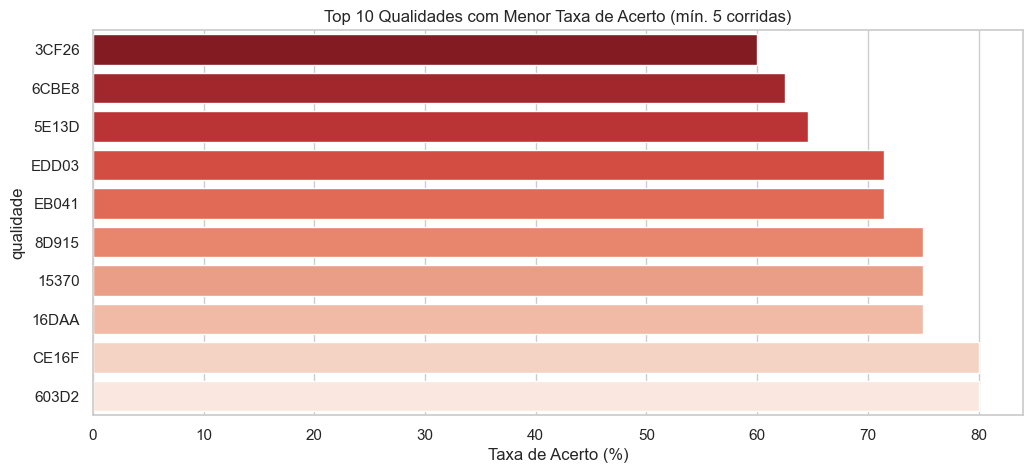

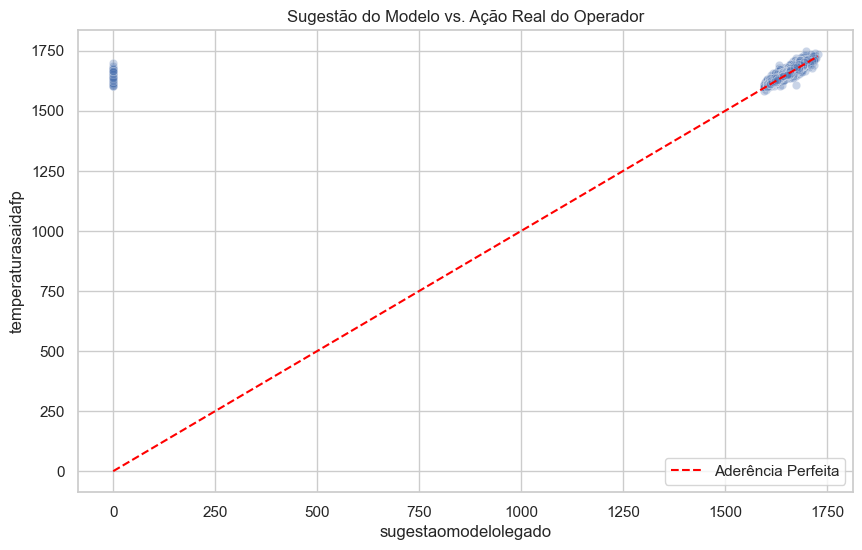

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo visual
sns.set_theme(style="whitegrid")

# Carregar os dados do arquivo
df = pd.read_csv('fundo_amanha_dados_mock_2026.csv')

# 1. Calcular o erro do modelo legado
df['erro_legado'] = df['temperaturamediareal'] - df['temperaturaobjetivada']

# 2. Critério de acerto: erro entre -10°C e +20°C
df['acerto_legado'] = (df['erro_legado'] >= -10) & (df['erro_legado'] <= 20)

# Taxa de acerto geral
taxa = df['acerto_legado'].mean() * 100
print(f'Taxa de acerto do modelo legado: {taxa:.1f}%')

# 3. Distribuição do erro
plt.figure(figsize=(10, 5))
sns.histplot(df['erro_legado'], kde=True, bins=40, color='steelblue')
plt.axvline(0, color='green', linestyle='--')
plt.axvline(-10, color='red', linestyle=':')
plt.axvline(20, color='orange', linestyle=':')
plt.title(f'Distribuição do Erro (Acerto: {taxa:.1f}%)')
plt.show()

# 4. Gráfico: Top 10 Piores Qualidades em Acerto
acerto_por_qualidade = df.groupby('qualidade')['acerto_legado'].agg(['mean','count'])
acerto_por_qualidade['mean'] *= 100
piores_qualidades = acerto_por_qualidade[acerto_por_qualidade['count'] > 5].sort_values('mean').head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=piores_qualidades['mean'], y=piores_qualidades.index, palette='Reds_r')
plt.title('Top 10 Qualidades com Menor Taxa de Acerto (mín. 5 corridas)')
plt.xlabel('Taxa de Acerto (%)')
plt.show()

# 5. Gráfico: Comportamento do Operador vs Legado
df['diferenca_operador_legado'] = df['temperaturasaidafp'] - df['sugestaomodelolegado']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sugestaomodelolegado', y='temperaturasaidafp', alpha=0.3)
plt.plot([df['sugestaomodelolegado'].min(), df['sugestaomodelolegado'].max()],
         [df['sugestaomodelolegado'].min(), df['sugestaomodelolegado'].max()],
         color='red', linestyle='--', label='Aderência Perfeita')
plt.title('Sugestão do Modelo vs. Ação Real do Operador')
plt.legend()
plt.show()

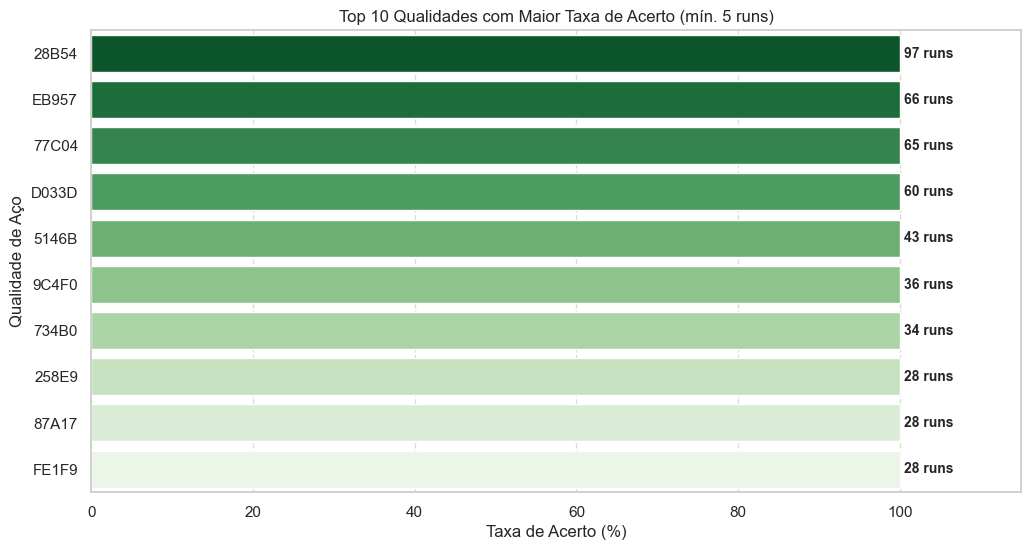

In [83]:
# 1. Calcular a taxa de acerto e contagem por qualidade
melhores_qualidades = df.groupby('qualidade')['acerto_legado'].agg(['mean', 'count'])
melhores_qualidades['mean'] *= 100

# 2. Filtrar qualidades com um volume mínimo de runs (ex: > 5) para evitar 100% de acerto com apenas 1 corrida
melhores_qualidades_filtradas = melhores_qualidades[melhores_qualidades['count'] >= 5].sort_values(by=['mean', 'count'], ascending=False).head(10)

# 3. Plotar as melhores qualidades
plt.figure(figsize=(12, 6))
sns.barplot(
    x=melhores_qualidades_filtradas['mean'],
    y=melhores_qualidades_filtradas.index,
    hue=melhores_qualidades_filtradas.index,
    palette='Greens_r',
    legend=False
)

# Adicionar os rótulos de contagem de runs nas barras
for i, (valor, count) in enumerate(zip(melhores_qualidades_filtradas['mean'], melhores_qualidades_filtradas['count'])):
    plt.text(valor + 0.5, i, f'{count} runs', va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 Qualidades com Maior Taxa de Acerto (mín. 5 runs)')
plt.xlabel('Taxa de Acerto (%)')
plt.ylabel('Qualidade de Aço')
plt.xlim(0, 115) # Espaço para o texto das runs
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Principais Correlações Identificadas
Com base na matriz de correlação calculada anteriormente, aqui estão os pares de variáveis com maior impacto mútuo (positiva ou negativamente):

In [84]:
# Filtrando apenas correlações muito fortes (acima de 0.7 ou abaixo de -0.7)
principais_correlacoes = correlation_df[correlation_df['Abs_Correlation'] > 0.7].drop_duplicates(subset=['Abs_Correlation'])

display(principais_correlacoes[['Variable 1', 'Variable 2', 'Correlation']].style.background_gradient(cmap='coolwarm'))

,Variable 1,Variable 2,Correlation
8,c_max,c_min,0.995815
13,corridasciclo,tempociclo,0.992731
20,sugestaomodelolegado,temperaturasaidafp,0.917193
9,c_max,temperaturaliquidus,-0.887771
4,c_min,temperaturaliquidus,-0.881976
22,temperaturamediareal,temperaturaobjetivada,0.825594
14,temperaturaliquidus,temperaturaobjetivada,0.815504
10,c_max,temperaturaobjetivada,-0.764050
5,c_min,temperaturaobjetivada,-0.756635
16,temperaturaliquidus,temperaturamediareal,0.721733


### Correlações Filtradas (R >= 0.6)
Exibindo apenas pares de variáveis com correlação absoluta igual ou superior a 0.6.

,Variable 1,Variable 2,Correlation
8,c_max,c_min,0.995815
13,corridasciclo,tempociclo,0.992731
20,sugestaomodelolegado,temperaturasaidafp,0.917193
9,c_max,temperaturaliquidus,-0.887771
4,c_min,temperaturaliquidus,-0.881976
22,temperaturamediareal,temperaturaobjetivada,0.825594
14,temperaturaliquidus,temperaturaobjetivada,0.815504
10,c_max,temperaturaobjetivada,-0.764050
5,c_min,temperaturaobjetivada,-0.756635
16,temperaturaliquidus,temperaturamediareal,0.721733


C:\Users\Usuário\AppData\Local\Temp\ipykernel_6016\2903146932.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=correlacoes_06, x='Correlation', y=correlacoes_06['Variable 1'] + ' vs ' + correlacoes_06['Variable 2'], palette='RdYlBu_r')


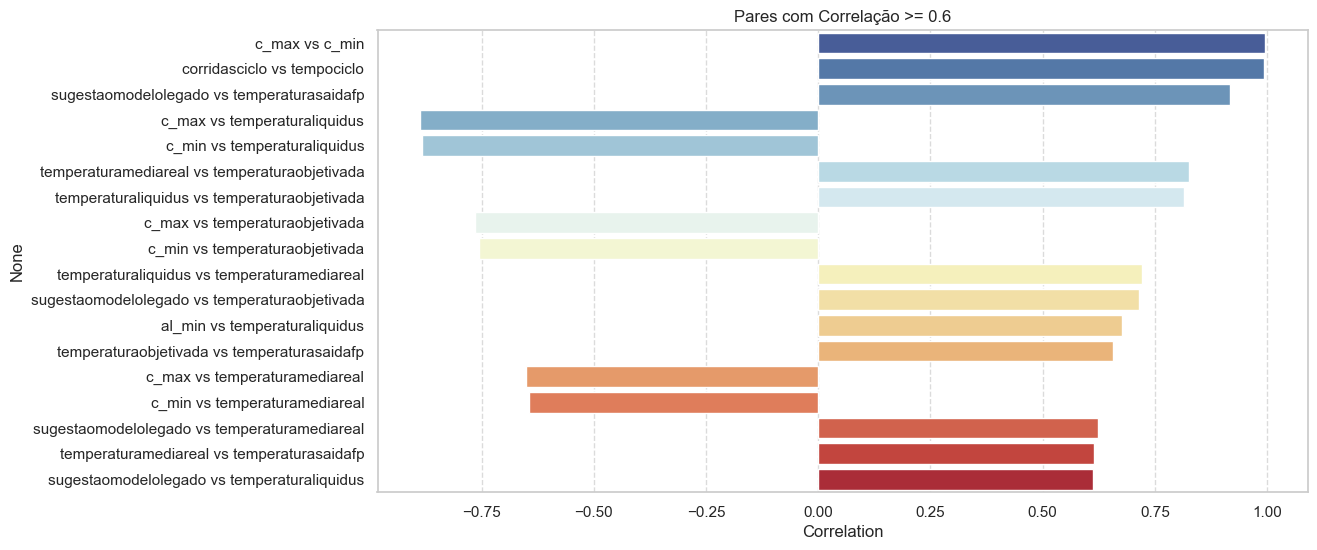

In [85]:
# Filtrando correlações a partir de 0.6
correlacoes_06 = correlation_df[correlation_df['Abs_Correlation'] >= 0.6].drop_duplicates(subset=['Abs_Correlation'])

# Exibindo a tabela formatada
display(correlacoes_06[['Variable 1', 'Variable 2', 'Correlation']].style.background_gradient(cmap='coolwarm'))

# Visualização em barras para comparação
plt.figure(figsize=(12, 6))
sns.barplot(data=correlacoes_06, x='Correlation', y=correlacoes_06['Variable 1'] + ' vs ' + correlacoes_06['Variable 2'], palette='RdYlBu_r')
plt.title('Pares com Correlação >= 0.6')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Visualização de Dispersão com Linha de Ajuste (R >= 0.6)
Gerando gráficos `regplot` para os pares de variáveis com correlação moderada a forte.

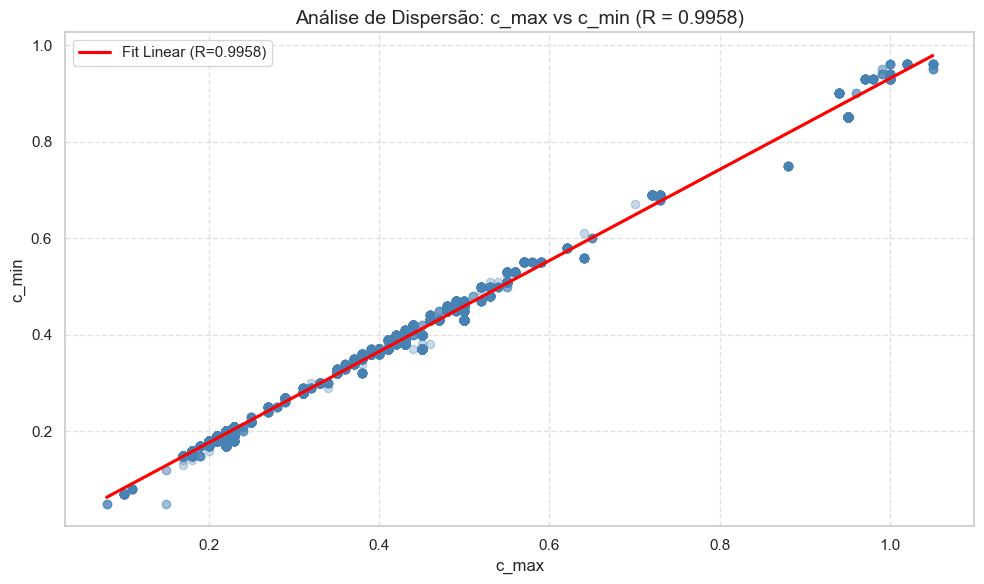

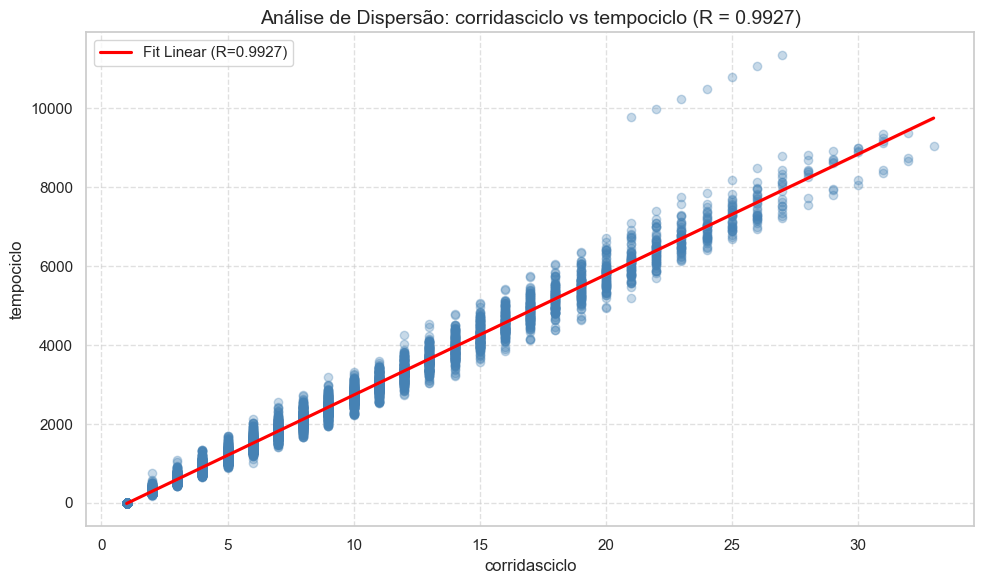

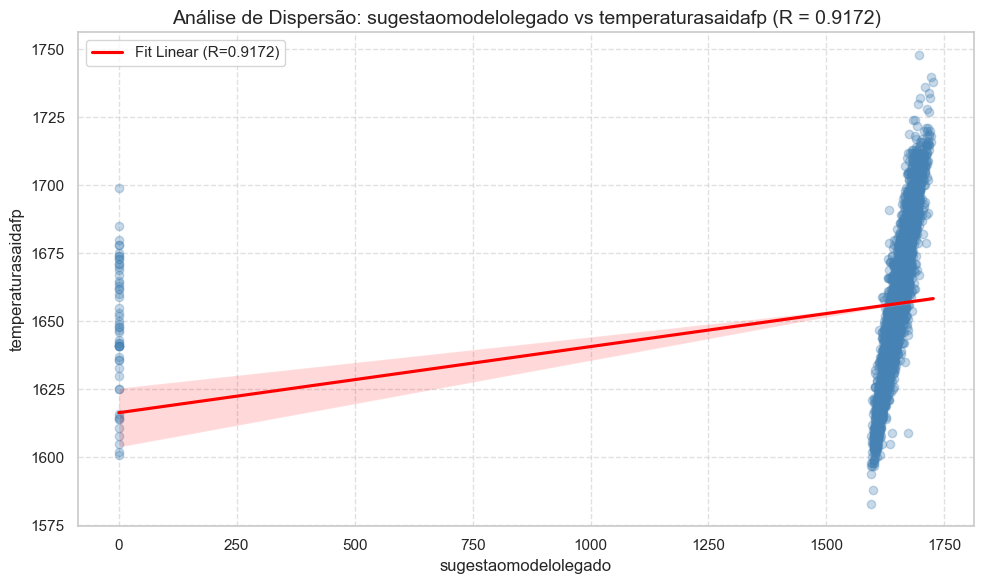

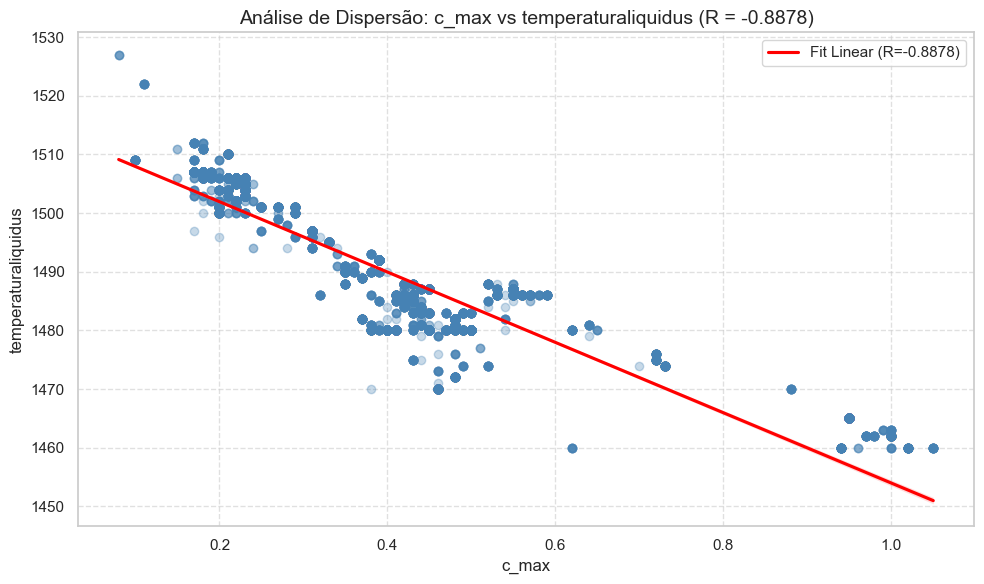

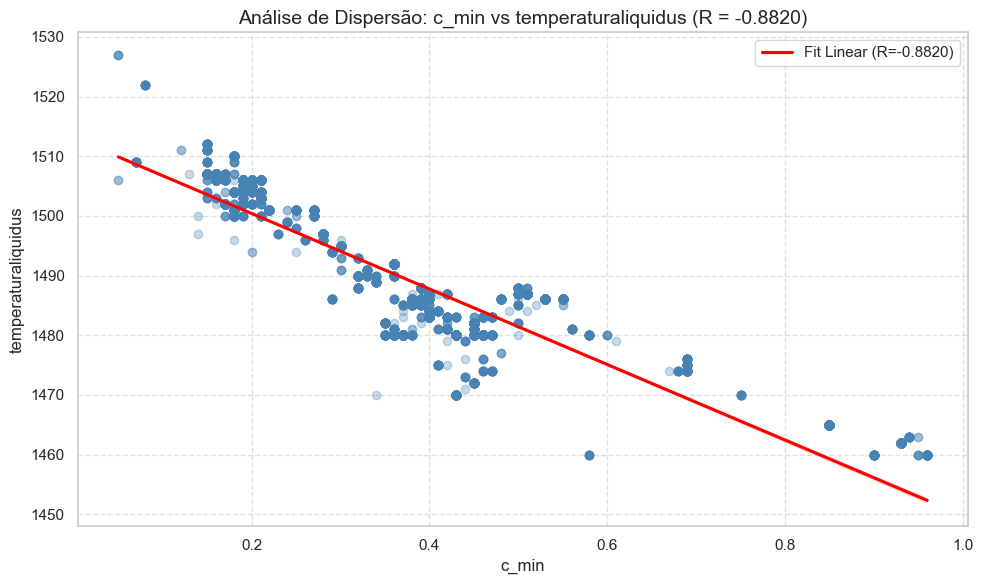

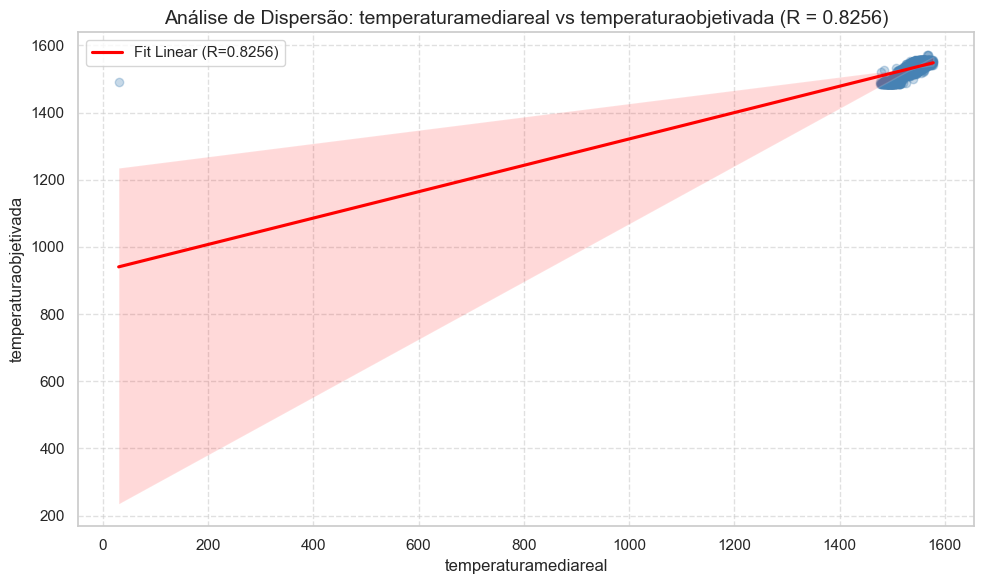

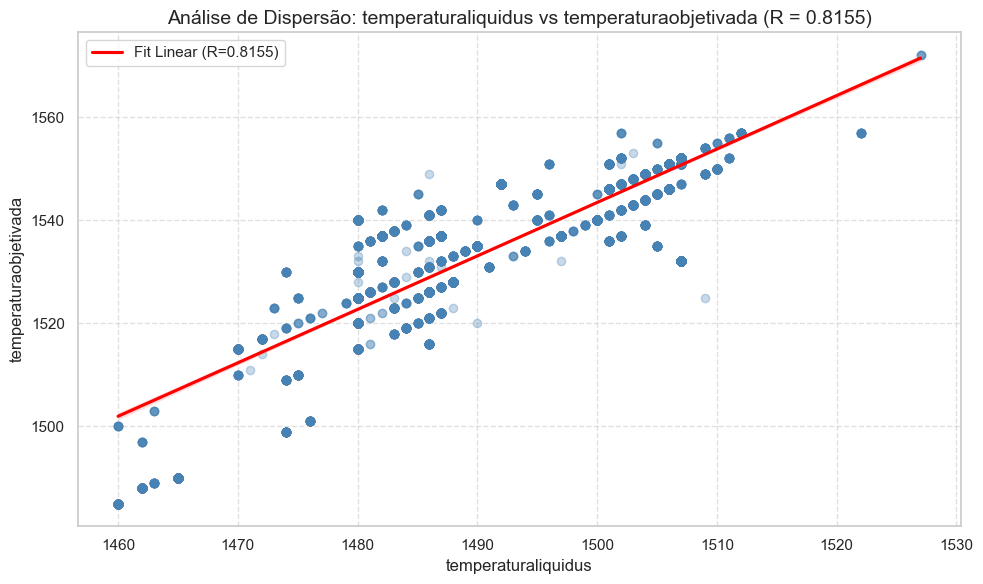

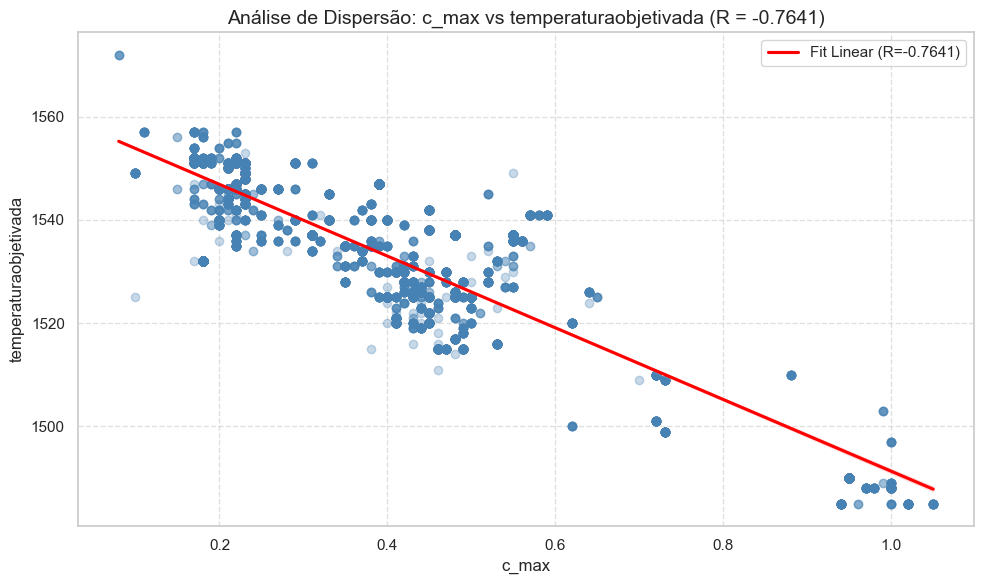

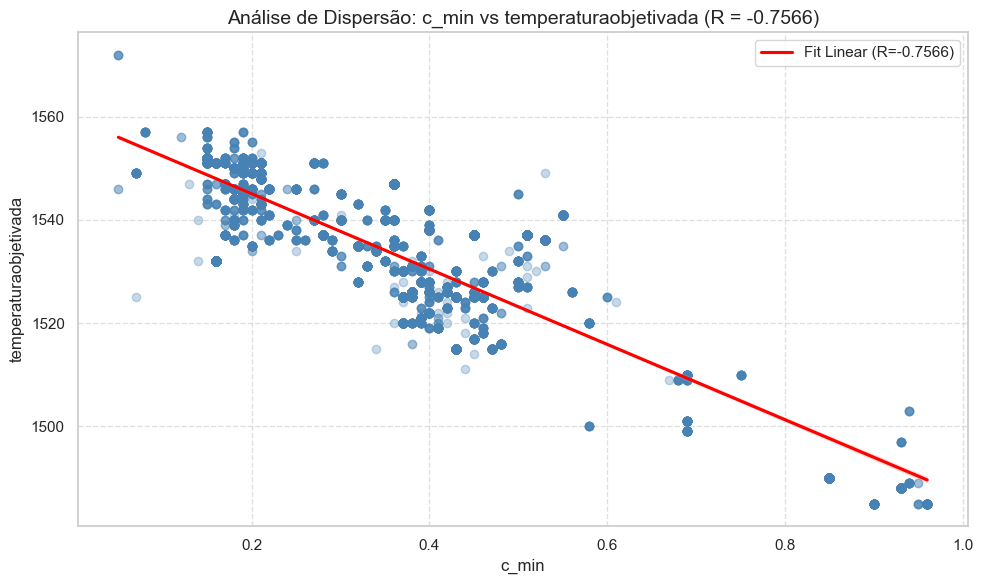

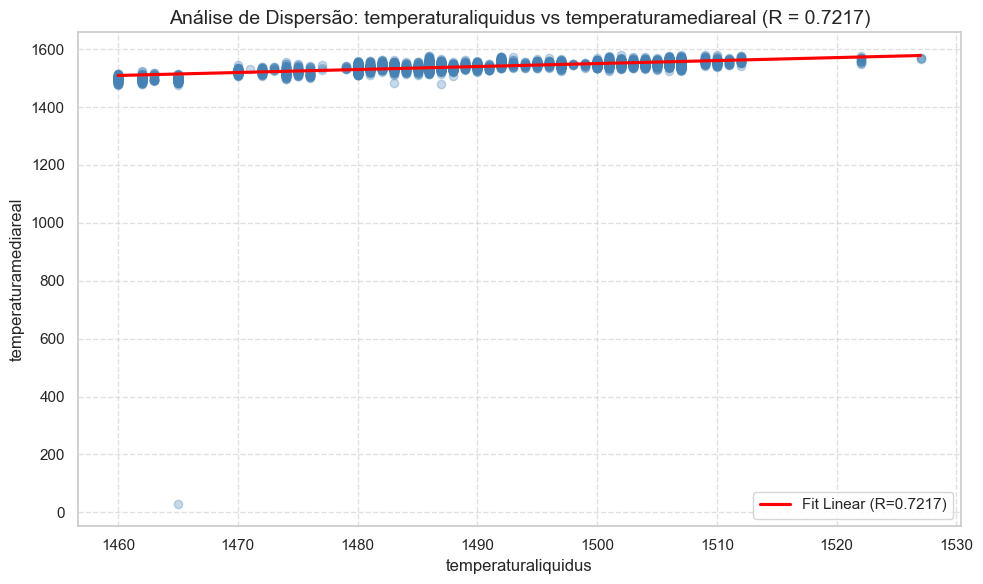

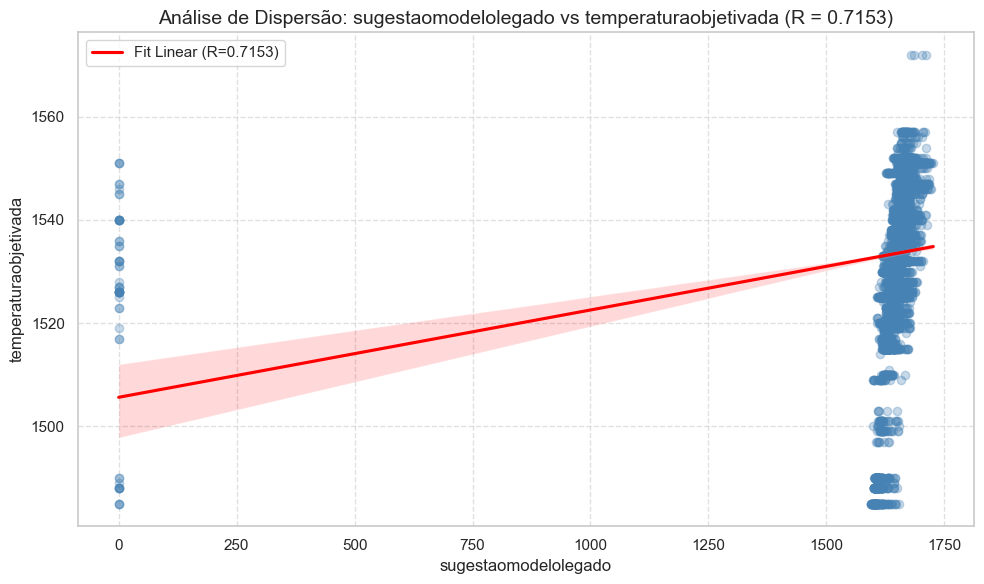

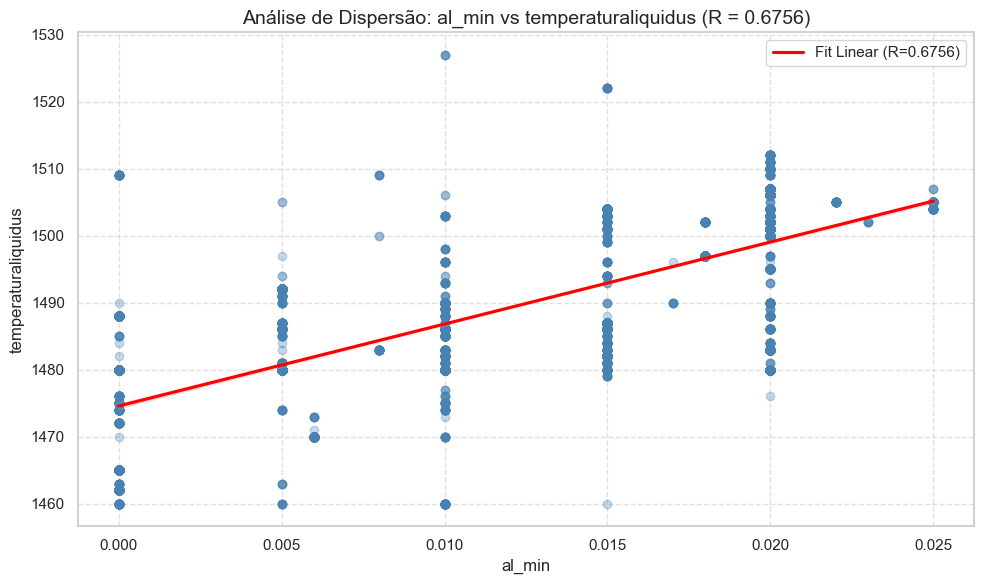

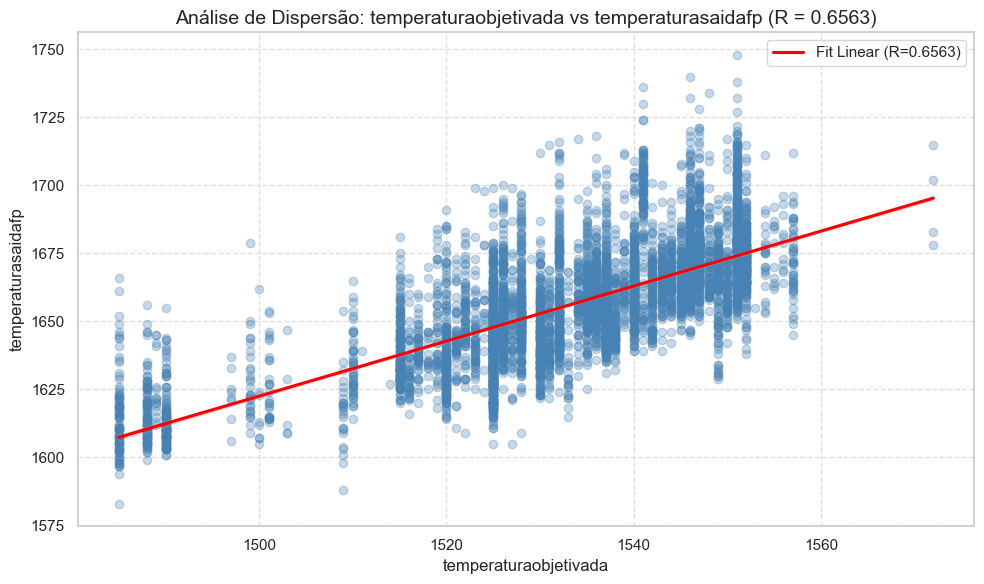

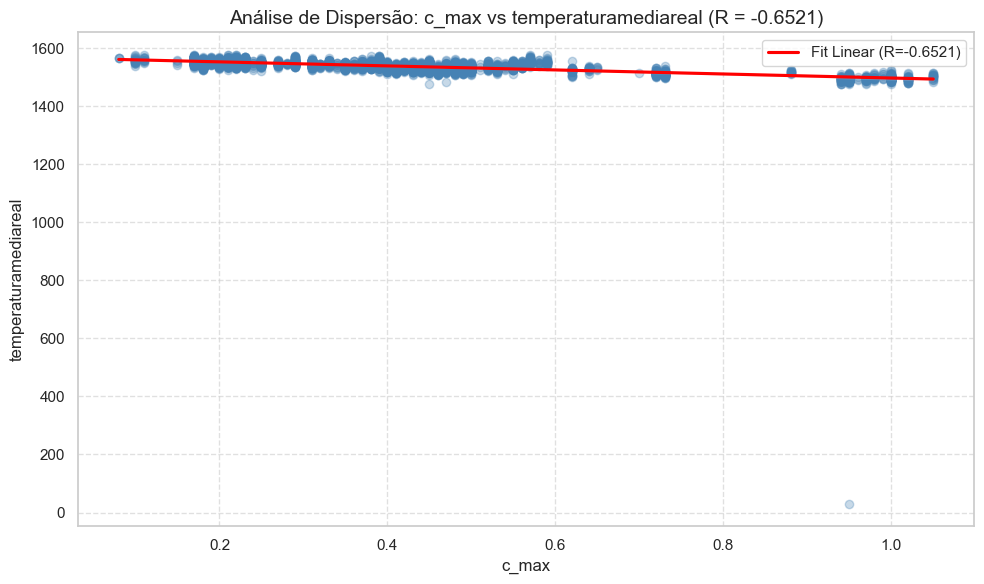

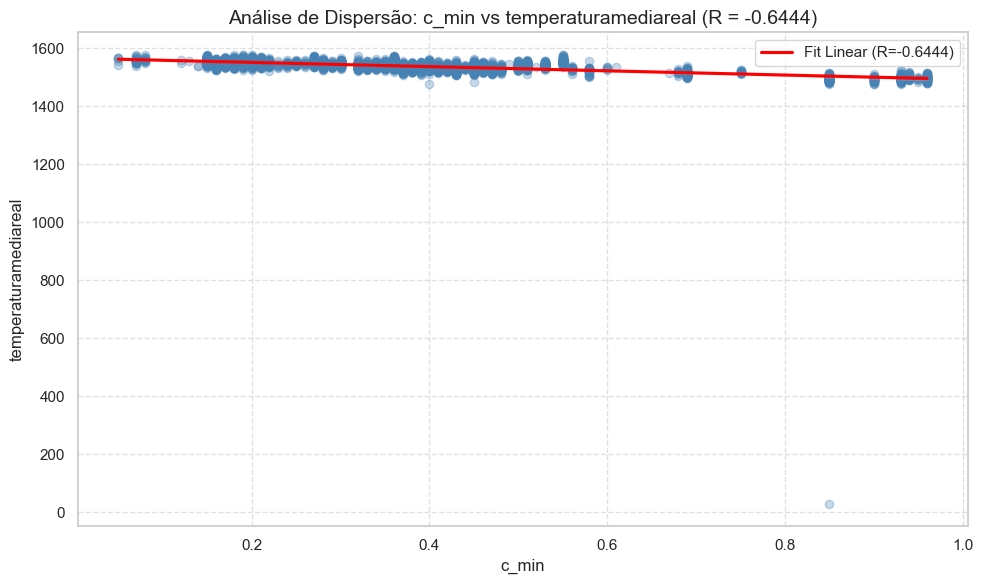

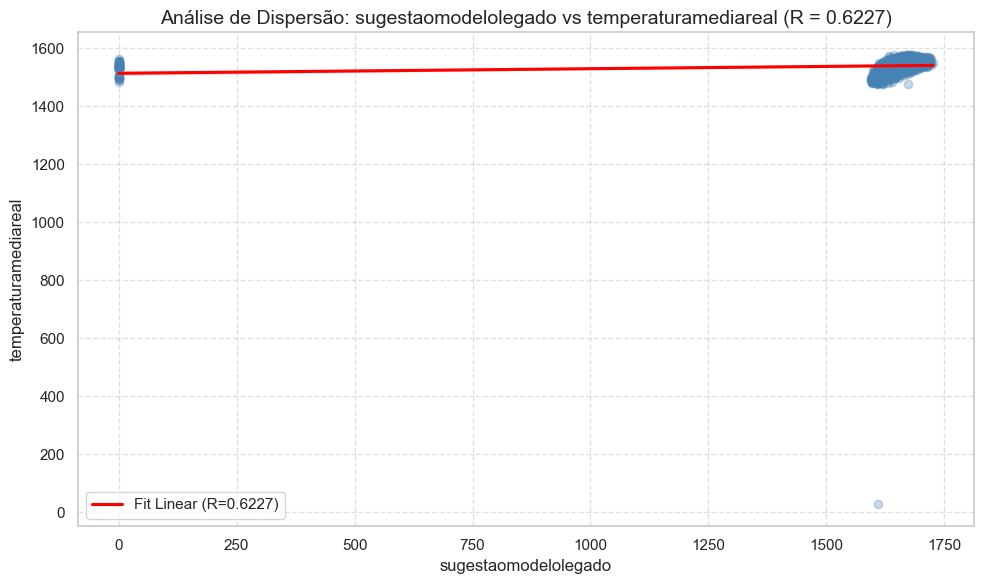

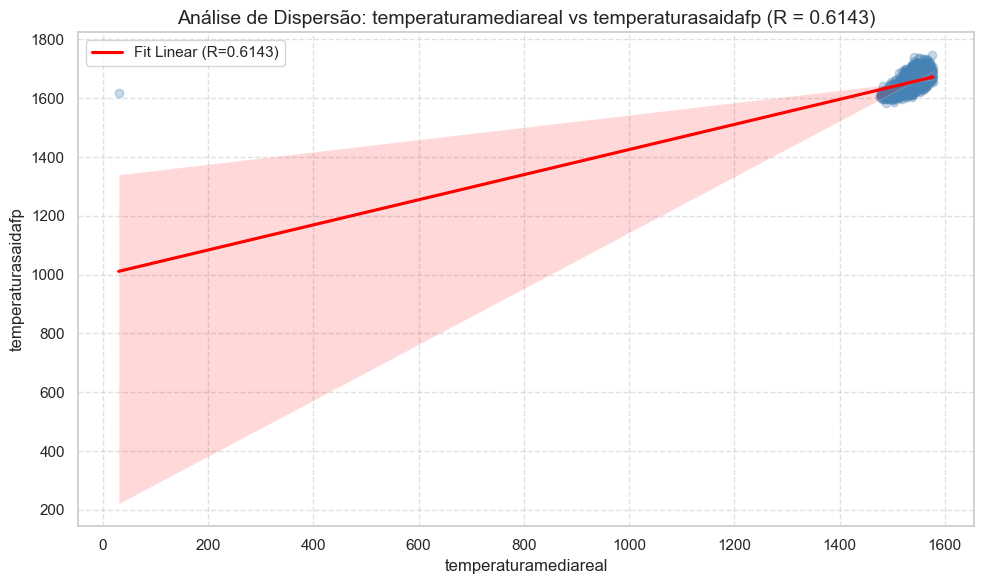

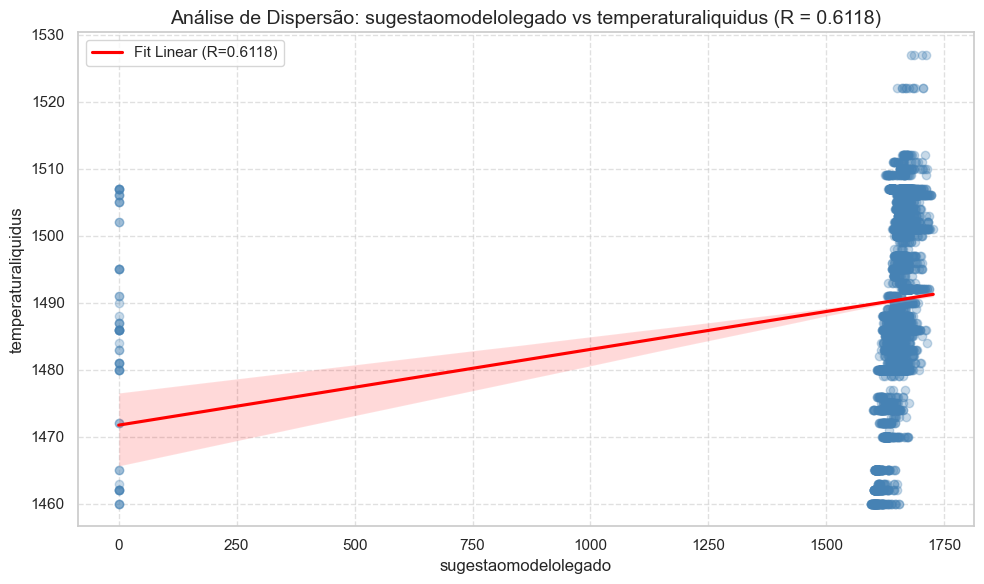

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Iterar sobre o dataframe de correlações filtradas (R >= 0.6)
for index, row in correlacoes_06.iterrows():
    v1 = row['Variable 1']
    v2 = row['Variable 2']
    corr_val = row['Correlation']

    plt.figure(figsize=(10, 6))
    # Plotando os dados dispersos com transparência (alpha) e a linha de regressão em vermelho
    sns.regplot(data=df, x=v1, y=v2,
                scatter_kws={'alpha': 0.3, 'color': 'steelblue'},
                line_kws={'color': 'red', 'label': f'Fit Linear (R={corr_val:.4f})'})

    # Título incluindo a correlação conforme solicitado
    plt.title(f'Análise de Dispersão: {v1} vs {v2} (R = {corr_val:.4f})', fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

### Análise de Dispersão com Correlação no Título (R >= 0.6)
Visualização detalhada dos pares de variáveis mais correlacionados.

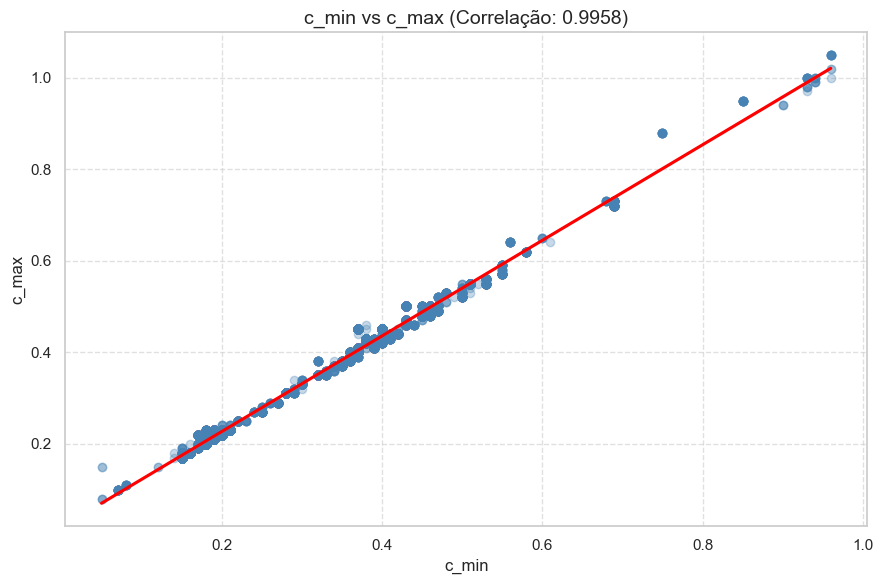

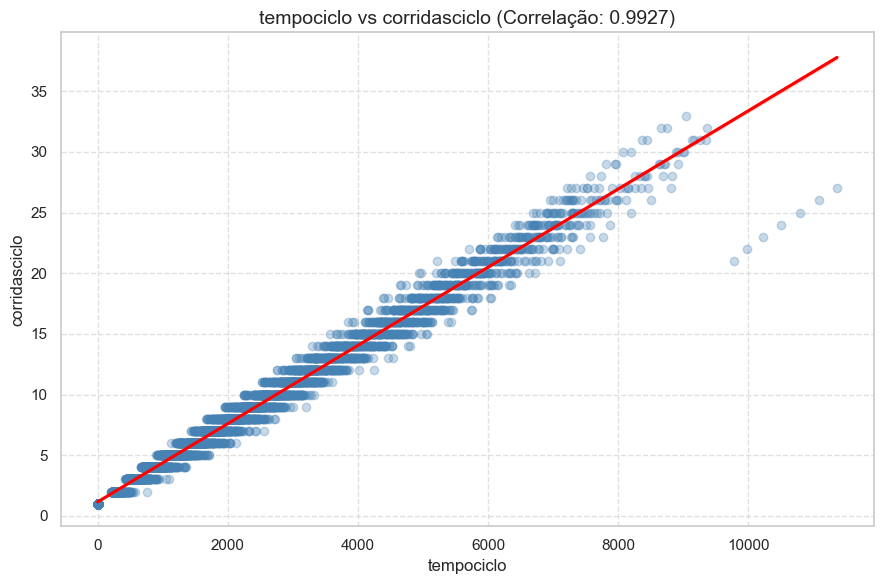

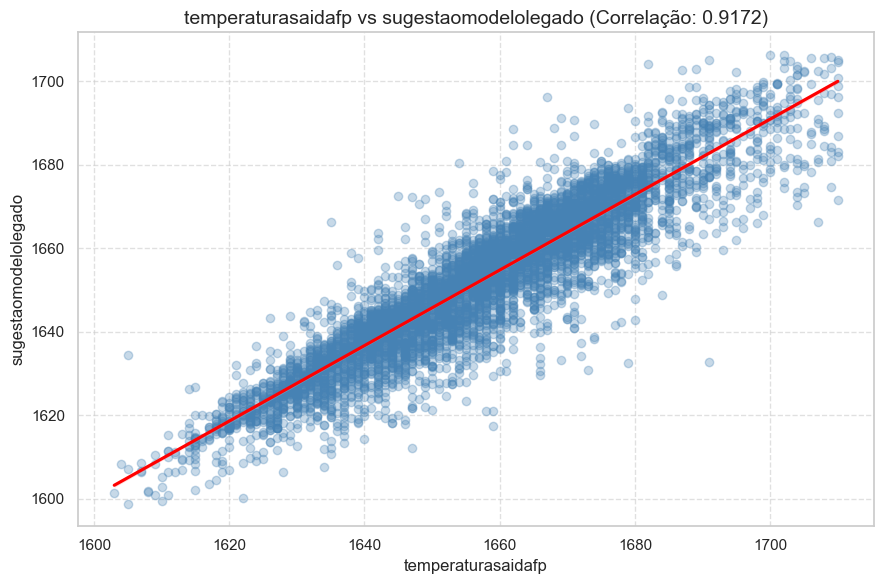

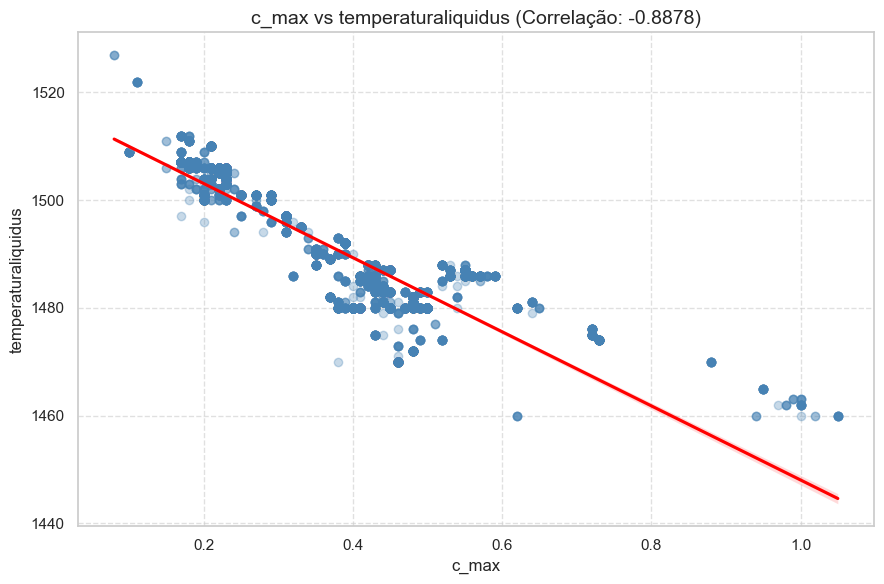

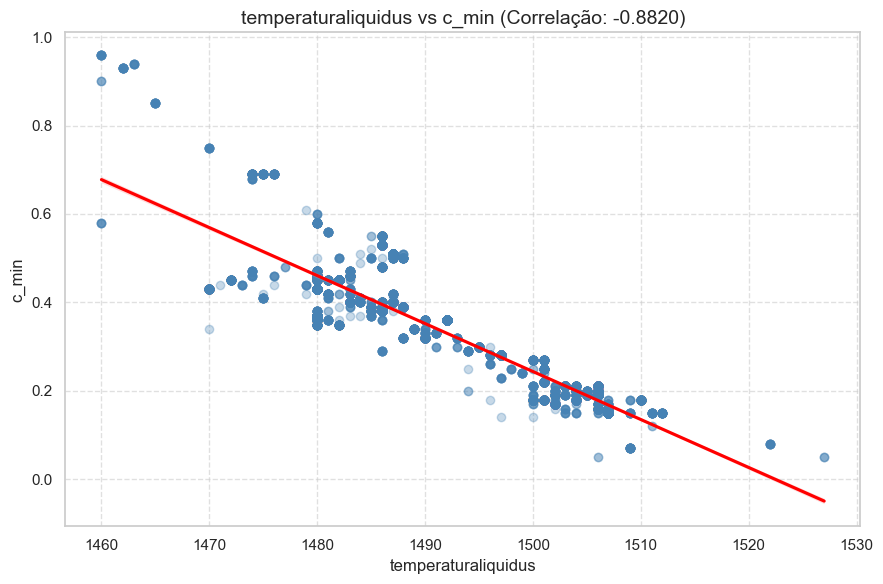

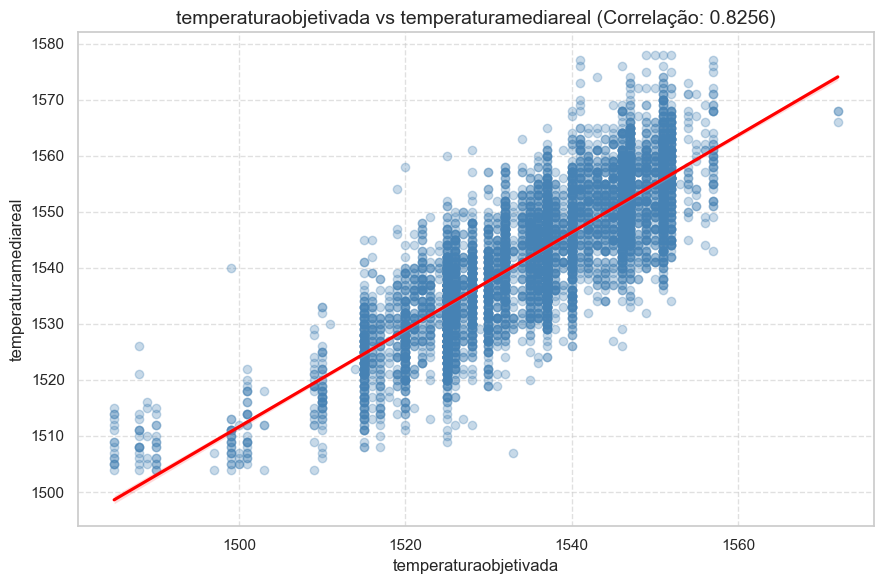

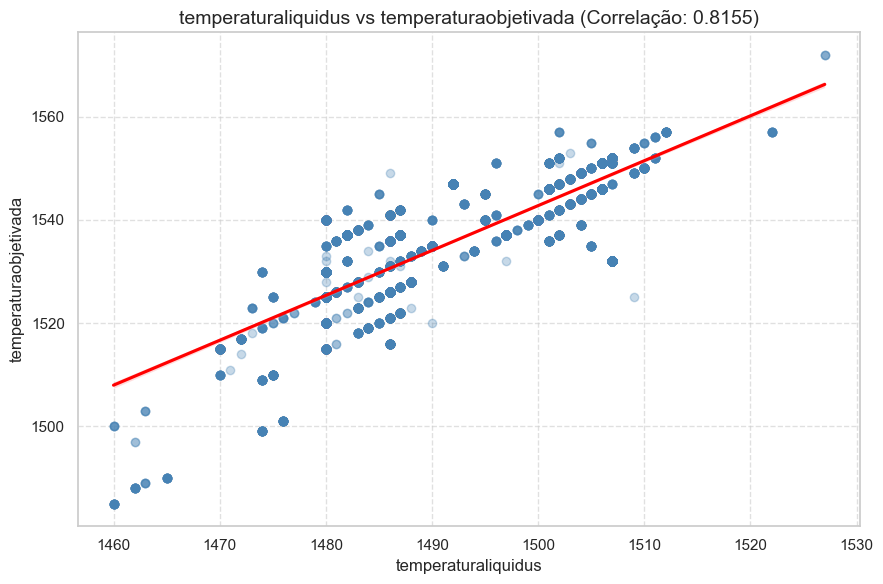

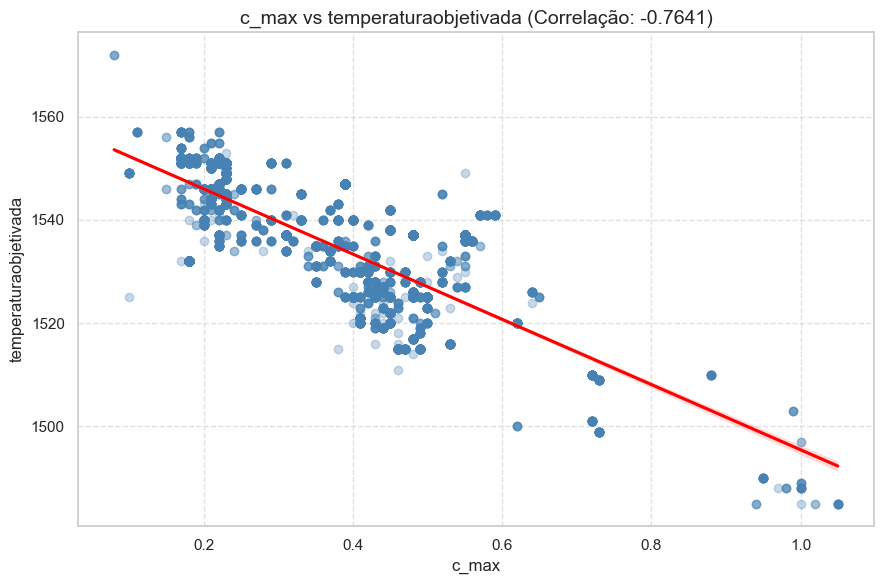

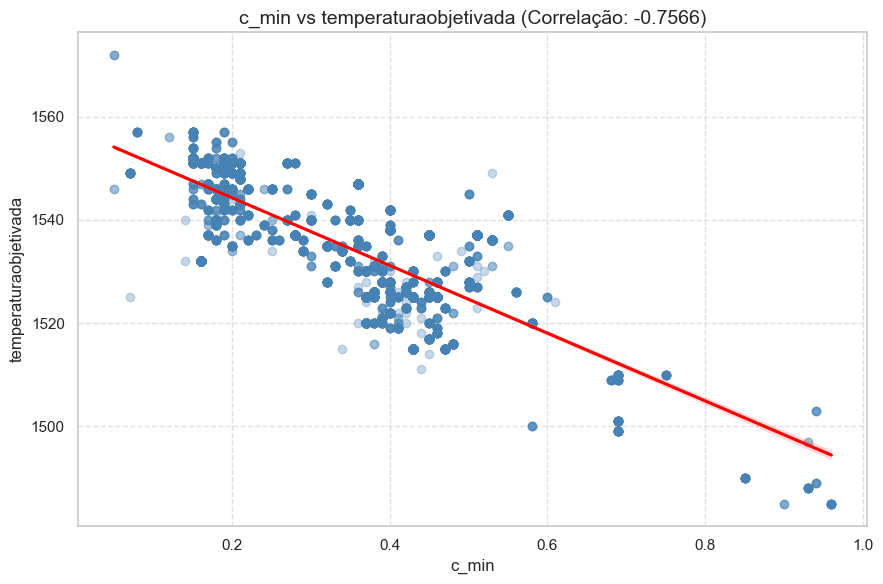

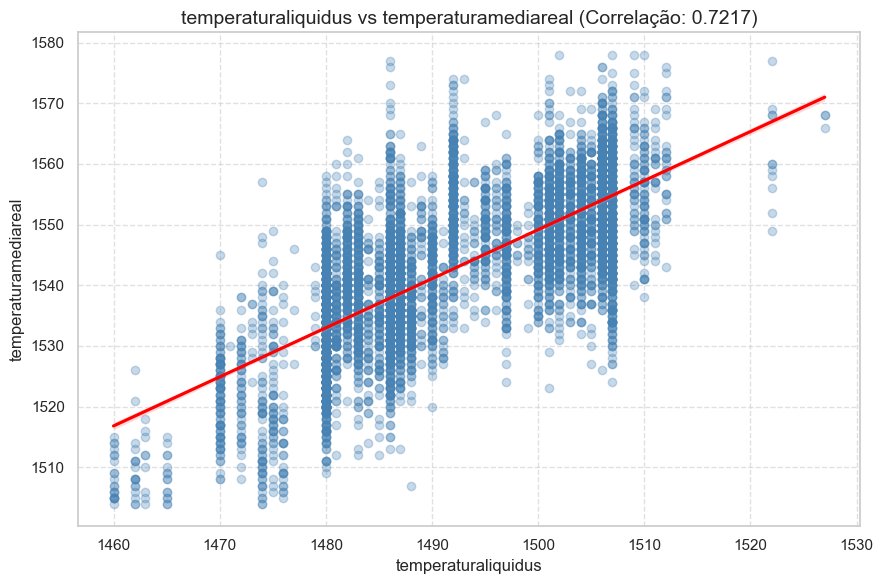

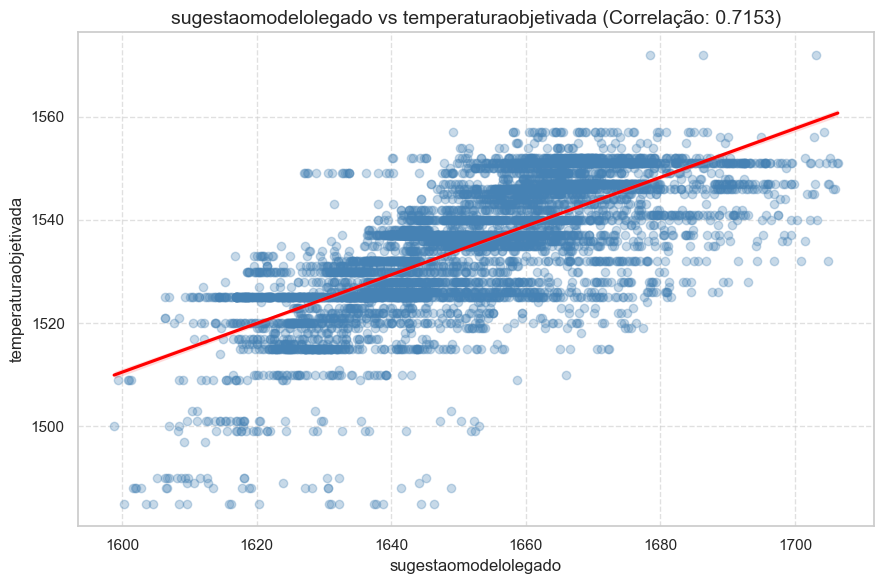

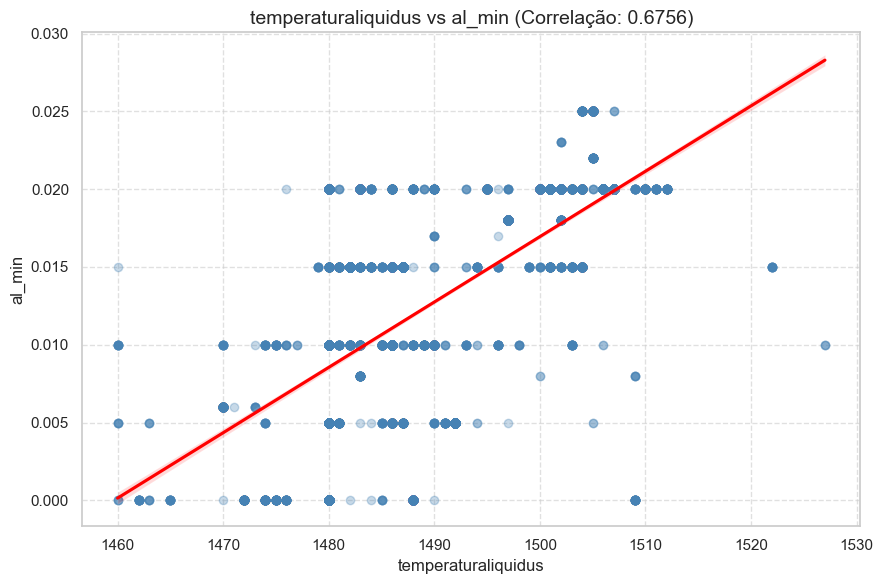

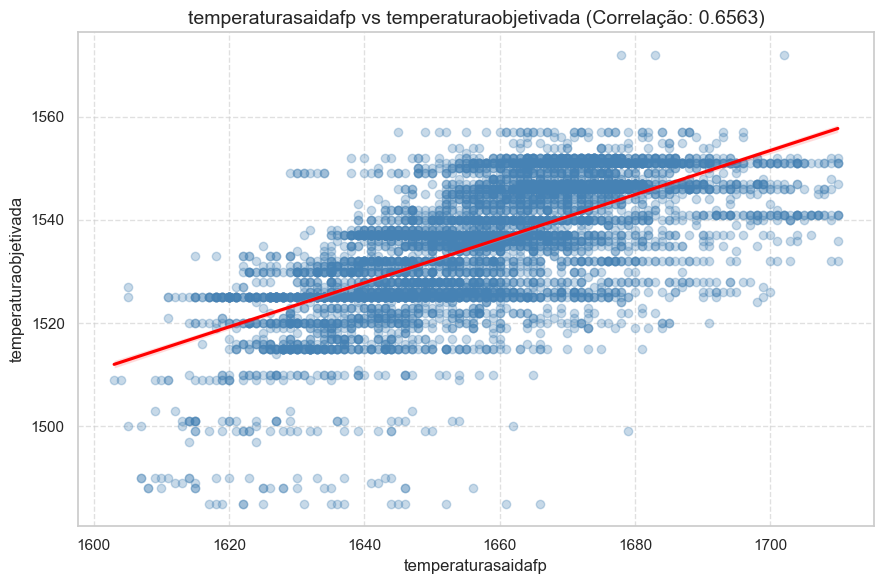

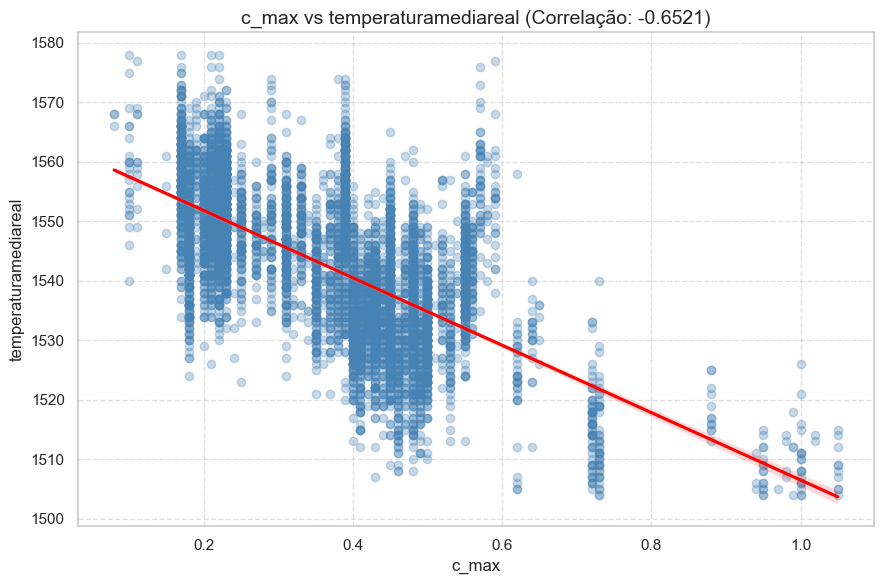

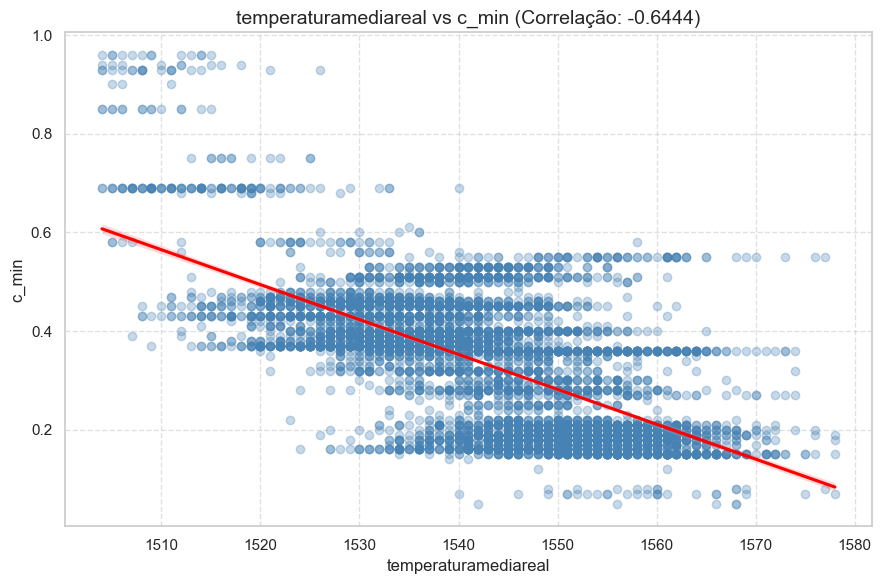

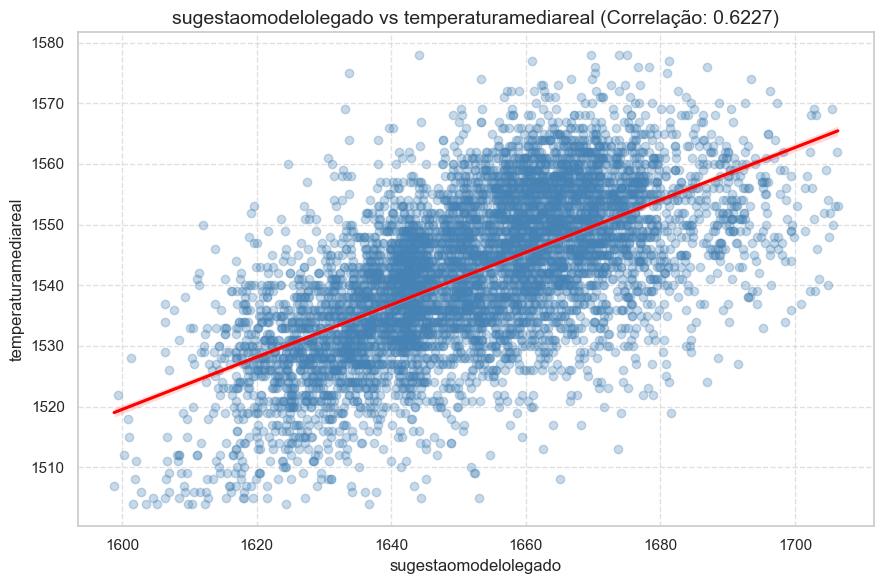

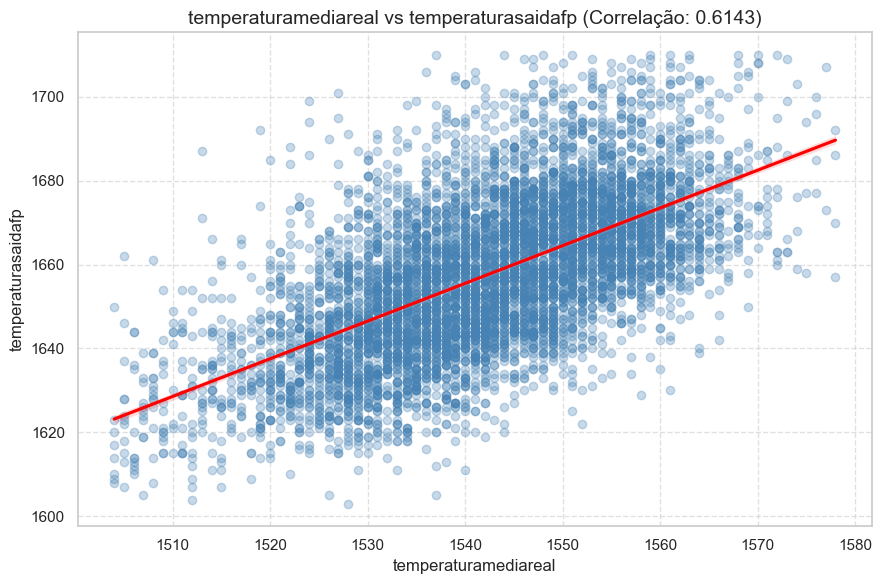

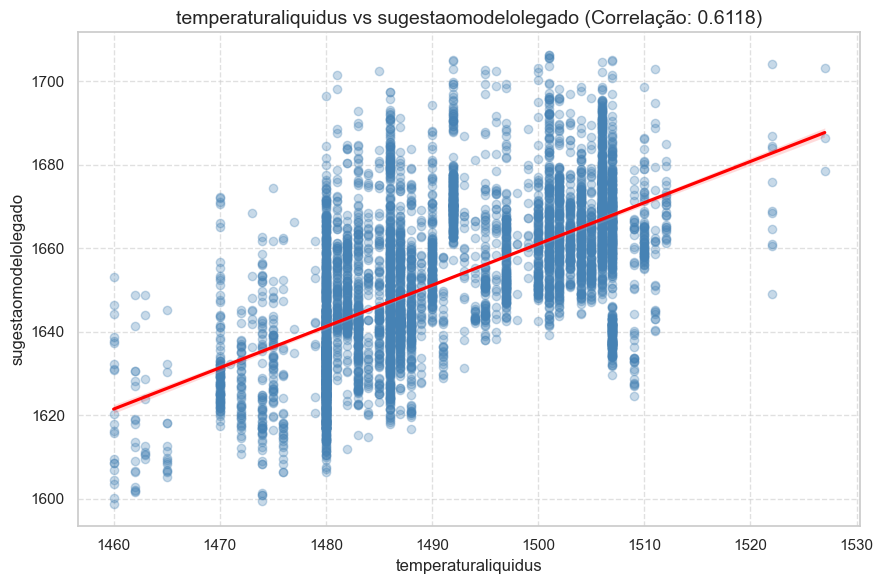

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrando correlações a partir de 0.6
correlacoes_finais = correlation_df[correlation_df['Abs_Correlation'] >= 0.6].drop_duplicates(subset=['Abs_Correlation'])

for index, row in correlacoes_finais.iterrows():
    v1 = row['Variable 1']
    v2 = row['Variable 2']
    r_val = row['Correlation']

    plt.figure(figsize=(9, 6))
    sns.regplot(data=df, x=v1, y=v2,
                scatter_kws={'alpha': 0.3, 'color': 'steelblue'},
                line_kws={'color': 'red'})

    # Título incluindo a correlação conforme solicitado
    plt.title(f'{v1} vs {v2} (Correlação: {r_val:.4f})', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

### Visualização de Dispersão para Correlações >= 0.6
Nesta seção, visualizamos a relação direta entre as variáveis que apresentaram os maiores índices de correlação.

In [103]:
print(df)

      corrida qualidade  secao  sequencia  sequenciatotal acoatual  al_min  \
0      132228     F4A5E    300        5.0             8.0        V   0.010   
1      132227     F4A5E    300        4.0             8.0        V   0.010   
2      132226     F4A5E    300        3.0             8.0        V   0.010   
3      132225     F4A5E    300        2.0             8.0        V   0.010   
4      132224     F4A5E    300        1.0             8.0        V   0.010   
...       ...       ...    ...        ...             ...      ...     ...   
7149   124600     FC47C    150        8.0            10.0        X   0.015   
7150   122844     E1B6A    300        4.0             7.0        X   0.020   
7151   122843     DCC51    300        3.0             7.0        V   0.010   
7152   122842     BCEE1    300        2.0             7.0        X   0.020   
7153   122837     9A58C    300        3.0             6.0        X   0.000   

      c_min  c_max  n_min  s_min  corridasciclo  panela  vidapa

In [104]:
df.head()

,corrida,qualidade,secao,sequencia,sequenciatotal,acoatual,al_min,c_min,c_max,n_min,s_min,corridasciclo,panela,vidapanela,temperaturaliquidus,temperaturaobjetivada,sugestaomodelolegado,temperaturasaidafp,tempociclo,temperaturamediareal
0,132228,F4A5E,300,5.0,8.0,V,0.01,0.35,0.37,0.01,0.045,6.0,7.0,32.0,1482.0,1532.0,1658.244263,1659.0,1593.0,1537.0
1,132227,F4A5E,300,4.0,8.0,V,0.01,0.35,0.37,0.01,0.045,5.0,2.0,16.0,1482.0,1532.0,1658.727173,1659.0,1364.0,1528.0
2,132226,F4A5E,300,3.0,8.0,V,0.01,0.35,0.37,0.01,0.045,4.0,4.0,50.0,1482.0,1532.0,1657.534302,1659.0,954.0,1533.0
3,132225,F4A5E,300,2.0,8.0,V,0.01,0.35,0.37,0.01,0.045,5.0,14.0,38.0,1482.0,1532.0,1649.176147,1652.0,1212.0,1546.0
4,132224,F4A5E,300,1.0,8.0,V,0.01,0.35,0.37,0.01,0.045,5.0,15.0,35.0,1482.0,1532.0,1661.008545,1664.0,1214.0,1534.0


In [105]:
df['qualidade'].nunique()

245

In [106]:
df['qualidade'].value_counts()

qualidade
2D42F    271
FC47C    218
4D097    214
889AE    207
CA2FD    198
        ... 
63654      1
37136      1
7C0D8      1
DFA45      1
345B1      1
Name: count, Length: 245, dtype: int64

In [107]:
# One-hot encode the 'qualidade' column
qualidade_dummies = pd.get_dummies(df['qualidade'], prefix='qualidade')
display(qualidade_dummies)
# If you want to add these columns to the original dataframe, uncomment:
# df = pd.concat([df, qualidade_dummies], axis=1)

,qualidade_000DC,qualidade_04ABF,qualidade_05E76,qualidade_05ED3,qualidade_083EB,qualidade_0AF2A,qualidade_0BFF6,qualidade_0D9F5,qualidade_0E7D0,qualidade_0F9E0,...,qualidade_FAAAA,qualidade_FB109,qualidade_FB416,qualidade_FB6D2,qualidade_FC47C,qualidade_FC570,qualidade_FE1F9,qualidade_FE39B,qualidade_FE93C,qualidade_FEDC9
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7149,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
7150,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7151,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7152,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
